# 00. Imports and functions

##### Main link see: https://lightautoml.readthedocs.io/en/v.0.4.0/pages/tutorials/Tutorial_1_basics.html

In [1]:
# Стандартные библиотеки Python
import os
import time
import re

# Научные и аналитические библиотеки
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Машинное обучение и метрики
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    balanced_accuracy_score
)
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import torch
from tqdm import tqdm


# LightAutoML incl report generation
from lightautoml.automl.presets.tabular_presets import TabularAutoML, TabularUtilizedAutoML
from lightautoml.dataset.roles import DatetimeRole
from lightautoml.tasks import Task
from lightautoml.report.report_deco import ReportDeco, ReportDecoUtilized
from lightautoml.addons.tabular_interpretation import SSWARM

# LightAutoML time-based cross-validation
from lightautoml.validation.np_iterators import TimeSeriesIterator

from lightautoml.reader.guess_roles import gini_normalized


'nlp' extra dependency package 'gensim' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'gensim' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


e:\Python312\lightautoml_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Python312\lightautoml_venv\Lib\site-packages\lightautoml\ml_algo\dl_model.py:42: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")
e:\Python312\lightautoml_venv\Lib\site-packages\lightautoml\text\embed.py:22: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")
e:\Python312\lightautoml_venv\Lib\site-packages\lightautoml\text\dl_transformers.py:25: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")


### ---- Stability functions

In [2]:
import os
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Настройка логгирования
#logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

LOG_FILE = "stability_tags.log"
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE, mode="a", encoding="utf-8"),
        logging.StreamHandler(),
    ],
    force=True,
)

def analyze_feature_stability_optimized_prev(df, feature_cols, date_col, save_plots = True):
    """
    Оптимизированный анализ стабильности признаков во времени.

    Параметры
    ----------
    df : pd.DataFrame
        Исходный датафрейм.
    feature_cols : list[str]
        Список колонок-признаков (например, TAG_*).
    date_col : str
        Название колонки с датой.

    Возвращает
    ----------
    dict
        {
            'fill_ratio_by_month': DataFrame - заполненность по месяцам,
            'mode_match_ratio_by_month': DataFrame - доля совпадений с модой по месяцам,
            'fill_stats': DataFrame - статистики по заполненности,
            'mode_stats': DataFrame - статистики по совпадению с модой,
            'stability_stats': DataFrame - объединённые статистики,
            'unstable_features': list[str] - список нестабильных признаков
        }
    """
    warnings.filterwarnings("ignore")
    logging.info("Начало анализа стабильности признаков")

    # --- 1. Подготовка данных -------------------------------------------------
    logging.info("Подготовка данных: приведение даты и фильтрация по дате, заполнение NaN нулями")
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # Фильтр по дате (по аналогии с исходным кодом)
    #df = df[df[date_col] >= "2023-06-01"]
    df["year_month"] = df[date_col].dt.to_period("M")

    # 2. Заменяем все пропуски на 0
    df_filled = df.copy()
    df_filled[feature_cols] = df_filled[feature_cols].fillna(0)

    # 3. Группировка по месяцам
    gb = df_filled.groupby("year_month")

    # 4. Заполненность = доля != 0
    logging.info("Расчет заполненности по месяцам")
    fill_ratio_by_month = gb[feature_cols].apply(lambda x: (x != 0).mean())

    # --- 5. Глобальная мода для каждой фичи (игнорируем 0) -------------------
    logging.info("Поиск глобальной моды для каждой фичи (игнорируя 0)")
    df_nonzero = df[feature_cols].replace(0, pd.NA).dropna(how="all")
    if not df_nonzero.empty:
        global_mode = df_nonzero.mode(dropna=True).iloc[0]
    else:
        global_mode = pd.Series(dtype=object)

    # Если мода не найдена для какого-то признака — исключаем его из расчёта
    valid_modes = global_mode.dropna()
    logging.info(f"Найдены моды для {len(valid_modes)} фич из {len(feature_cols)}")

    # --- 6. Доля совпадений с модой по месяцам --------------------------------
    logging.info("Расчет доли совпадений с модой по месяцам")
    if len(valid_modes) == 0:
        mode_match_ratio_by_month = pd.DataFrame(
            index=fill_ratio_by_month.index,
            columns=feature_cols,
            dtype=float,
        )
    else:
        subset_cols = valid_modes.index.tolist()
        mode_vals = valid_modes.to_dict()

        match_df = df_filled[["year_month"] + subset_cols].copy()
        for col in tqdm(subset_cols, desc="Расчет совпадений с модой"):
            match_df[col] = (match_df[col] == mode_vals[col]).astype(int)

        mode_match_by_month = match_df.groupby("year_month")[subset_cols].mean()

        mode_match_ratio_by_month = pd.DataFrame(
            index=fill_ratio_by_month.index,
            columns=feature_cols,
            dtype=float,
        )
        mode_match_ratio_by_month[subset_cols] = mode_match_by_month.reindex(fill_ratio_by_month.index)

    # --- 7. Статистика по заполненности ---------------------------------------
    logging.info("Расчет статистики заполненности")
    fill_stats = pd.DataFrame({
        "min_fill": fill_ratio_by_month.min(),
        "max_fill": fill_ratio_by_month.max(),
        "var_fill": fill_ratio_by_month.var(),
    })

    # --- 8. Статистика по совпадениям с модой ---------------------------------
    logging.info("Расчет статистики доли совпадений с модой")
    mode_stats = pd.DataFrame({
        "min_mode_match": mode_match_ratio_by_month.min(),
        "max_mode_match": mode_match_ratio_by_month.max(),
        "var_mode": mode_match_ratio_by_month.var(),
    })

    # --- 9. Объединённая таблица ----------------------------------------------
    stability_stats = fill_stats.join(mode_stats, how="outer")

    # --- 10. Адаптивные пороги дисперсии (95-й перцентиль) --------------------
    var_fill_clean = fill_stats["var_fill"].dropna()
    var_mode_clean = mode_stats["var_mode"].dropna()

    var_threshold_fill = var_fill_clean.quantile(0.95) if not var_fill_clean.empty else 0.0
    var_threshold_mode = var_mode_clean.quantile(0.95) if not var_mode_clean.empty else 0.0

    logging.info(f"Порог дисперсии заполненности (95%): {var_threshold_fill:.4f}")
    logging.info(f"Порог дисперсии совпадений с модой (95%): {var_threshold_mode:.4f}")

    # --- 11. Относительные изменения между месяцами ---------------------------
    fill_changes_rel = fill_ratio_by_month.pct_change().abs()
    fill_changes_rel = fill_changes_rel.replace([np.inf, -np.inf], np.nan)

    mode_changes_rel = mode_match_ratio_by_month.pct_change().abs()
    mode_changes_rel = mode_changes_rel.replace([np.inf, -np.inf], np.nan)

    # --- 12. Квантили: 2.5% и 97.5% ------------------------------------------
    q25_fill = fill_ratio_by_month.quantile(0.025, axis=0)
    q975_fill = fill_ratio_by_month.quantile(0.975, axis=0)

    q25_mode = mode_match_ratio_by_month.quantile(0.025, axis=0)
    q975_mode = mode_match_ratio_by_month.quantile(0.975, axis=0)

    # --- 13. Относительная разница (max - min) / min --------------------------
    min_fill = fill_ratio_by_month.min()
    max_fill = fill_ratio_by_month.max()
    rel_diff_fill = np.where(
        min_fill > 0,
        (max_fill - min_fill) / min_fill,
        np.where(max_fill > 0, np.inf, 0),
    )
    rel_diff_fill = pd.Series(rel_diff_fill, index=min_fill.index)

    min_mode = mode_match_ratio_by_month.min()
    max_mode = mode_match_ratio_by_month.max()
    rel_diff_mode = np.where(
        min_mode > 0,
        (max_mode - min_mode) / min_mode,
        np.where(max_mode > 0, np.inf, 0),
    )
    rel_diff_mode = pd.Series(rel_diff_mode, index=min_mode.index)

    rel_diff_threshold = 10  # оставляю ваш порог, комментарий можно поправить при желании
    unstable_by_diff_fill = set(rel_diff_fill[rel_diff_fill > rel_diff_threshold].index)
    unstable_by_diff_mode = set(rel_diff_mode[rel_diff_mode > rel_diff_threshold * 2].index)

    # --- 14. Абсолютный критерий: средняя заполненность < 0.01 ----------------
    mean_fill = fill_ratio_by_month.mean()
    unstable_by_critical_low_fill = set(mean_fill[mean_fill < 0.001].index)

    # --- 15. Критерий: низкая заполненность до 2025 года и высокая в 2025 -----
    logging.info("Поиск признаков с низкой заполненностью до 2025 года и высокой в 2025 году")

    fill_before_2025 = fill_ratio_by_month[fill_ratio_by_month.index.year < 2025]
    fill_in_2025 = fill_ratio_by_month[fill_ratio_by_month.index.year == 2025]

    mean_fill_before_2025 = fill_before_2025.mean()
    mean_fill_in_2025 = fill_in_2025.mean()

    low_fill_before_2025 = mean_fill_before_2025[mean_fill_before_2025 < 0.1].index
    high_fill_in_2025 = mean_fill_in_2025[mean_fill_in_2025 >= 0.1].index

    # Признаки, которые были низко заполнены до 2025, но высоко заполнены в 2025
    stable_by_fill_change = set(low_fill_before_2025).intersection(high_fill_in_2025)

    # Исключаем их из списка нестабильных по критически низкой заполненности
    unstable_by_critical_low_fill = unstable_by_critical_low_fill - stable_by_fill_change

    # --- 16. Дисперсия --------------------------------------------------------
    unstable_by_var_fill = set(stability_stats[stability_stats["var_fill"] > var_threshold_fill].index)
    unstable_by_var_mode = set(stability_stats[stability_stats["var_mode"] > var_threshold_mode].index)

    # --- 17. Относительные изменения (более 3 месяцев) ------------------------
    n_rel_anom_fill = (fill_changes_rel > 0.99).sum()
    n_rel_anom_mode = (mode_changes_rel > 0.99).sum()
    unstable_by_rel_change_fill = set(n_rel_anom_fill[n_rel_anom_fill > 2].index)
    unstable_by_rel_change_mode = set(n_rel_anom_mode[n_rel_anom_mode > 2].index)

    # --- 18. Экстремумы (<2.5% или >97.5%, более 2 месяцев) -------------------
    n_low_fill = (fill_ratio_by_month < q25_fill).sum()
    n_high_fill = (fill_ratio_by_month > q975_fill).sum()
    n_low_mode = (mode_match_ratio_by_month < q25_mode).sum()
    n_high_mode = (mode_match_ratio_by_month > q975_mode).sum()

    unstable_by_extreme_fill_low = set(n_low_fill[n_low_fill > 2].index)
    unstable_by_extreme_fill_high = set(n_high_fill[n_high_fill > 2].index)
    unstable_by_extreme_mode_low = set(n_low_mode[n_low_mode > 2].index)
    unstable_by_extreme_mode_high = set(n_high_mode[n_high_mode > 2].index)

    # --- 19. Фильтр «признак отключён в 2025» ---------------------------------
    logging.info("Поиск признаков, отключённых в 2025 г. (>6 месяцев с 0 < fill < 0.001)")
    fill_2025 = fill_ratio_by_month[fill_ratio_by_month.index.year == 2025]
    n_near_zero_2025 = ((fill_2025 > 0) & (fill_2025 < 0.001)).sum()
    switched_off_2025 = set(n_near_zero_2025[n_near_zero_2025 > 6].index)

    # --- 20. Объединение всех критериев ---------------------------------------
    unstable_features = sorted(list(
        unstable_by_critical_low_fill |
        switched_off_2025 |
        unstable_by_var_fill |
        unstable_by_var_mode |
        unstable_by_rel_change_fill |
        unstable_by_rel_change_mode |
        unstable_by_extreme_fill_low |
        unstable_by_extreme_fill_high |
        unstable_by_extreme_mode_low |
        unstable_by_extreme_mode_high 
    ))

    stable_features = list(set(set(feature_cols) - set(unstable_features))) ### ADJUST

    # --- 21. Логгирование ------------------------------------------------------
    logging.info(f"Найдено {len(unstable_features)} нестабильных фич:")
    logging.info(f"  • fill < 0.001 (среднее): {len(unstable_by_critical_low_fill)}")
    logging.info(f"  • fill ~ 0 (отключены в 2025): {len(switched_off_2025)}")
    logging.info(f"  • var_fill > 95% перцентиля: {len(unstable_by_var_fill)}")
    logging.info(f"  • var_mode > 95% перцентиля: {len(unstable_by_var_mode)}")
    logging.info(f"  • rel_change_fill > 99% (более 3 мес): {len(unstable_by_rel_change_fill)}")
    logging.info(f"  • rel_change_mode > 99% (более 3 мес): {len(unstable_by_rel_change_mode)}")
    logging.info(f"  • extreme_fill_low (<2.5%, более 2 мес): {len(unstable_by_extreme_fill_low)}")
    logging.info(f"  • extreme_fill_high (>97.5%, более 2 мес): {len(unstable_by_extreme_fill_high)}")
    logging.info(f"  • extreme_mode_low (<2.5%, более 2 мес): {len(unstable_by_extreme_mode_low)}")
    logging.info(f"  • extreme_mode_high (>97.5%, более 2 мес): {len(unstable_by_extreme_mode_high)}")
    

    # --- 22. Построение и сохранение графиков ---------------------------------
    if save_plots:
        logging.info("Построение и сохранение графиков для нестабильных фич")

        output_dir = "FEATURES_STABILITY_UNSTABLE"
        os.makedirs(output_dir, exist_ok=True)

        x_dates = fill_ratio_by_month.index.to_timestamp()

        for feat in unstable_features:
            fig, ax = plt.subplots(figsize=(10, 5))

            ax.plot(x_dates, fill_ratio_by_month[feat].values,
                    label="Заполненность (≠0)", marker="o")
            ax.plot(x_dates, mode_match_ratio_by_month[feat].values,
                    label="Совпадение с модой", marker="x")

            ax.set_title(f"Фича: {feat}")
            ax.set_ylabel("Доля")
            ax.set_xlabel("Месяц")
            ax.legend()
            fig.autofmt_xdate()
            fig.tight_layout()

            # безопасное имя файла
            safe_name = "".join(
                c if c.isalnum() or c in ("_", "-") else "_" for c in str(feat)
            )
            save_path = os.path.join(output_dir, f"{safe_name}.png")
            fig.savefig(save_path, dpi=200)
            plt.close(fig)

            logging.info(f"Сохранён график: {save_path}")

# Построение стабильных
        if save_plots:
            logging.info("Построение и сохранение графиков для стабильных фич")

            output_dir = "FEATURES_STABILITY_STABLE"
            os.makedirs(output_dir, exist_ok=True)

            x_dates = fill_ratio_by_month.index.to_timestamp()

            for feat in stable_features:
                fig, ax = plt.subplots(figsize=(10, 5))

                ax.plot(x_dates, fill_ratio_by_month[feat].values,
                        label="Заполненность (≠0)", marker="o")
                ax.plot(x_dates, mode_match_ratio_by_month[feat].values,
                        label="Совпадение с модой", marker="x")

                ax.set_title(f"Фича: {feat}")
                ax.set_ylabel("Доля")
                ax.set_xlabel("Месяц")
                ax.legend()
                fig.autofmt_xdate()
                fig.tight_layout()

                # безопасное имя файла
                safe_name = "".join(
                    c if c.isalnum() or c in ("_", "-") else "_" for c in str(feat)
                )
                save_path = os.path.join(output_dir, f"{safe_name}.png")
                fig.savefig(save_path, dpi=200)
                plt.close(fig)

                logging.info(f"Сохранён график: {save_path}")

    logging.info("Анализ завершен")

    return {
        "fill_ratio_by_month": fill_ratio_by_month,
        "mode_match_ratio_by_month": mode_match_ratio_by_month,
        "fill_stats": fill_stats,
        "mode_stats": mode_stats,
        "stability_stats": stability_stats,
        "unstable_features": unstable_features,
        "stable_features": stable_features,
    }


In [3]:

import os
import matplotlib.pyplot as matplotlib_plt
import matplotlib.image as mpimg

def plot_tag_images(folder_path, tags, cols=3):
    """
    Отображает изображения из папки по списку названий тегов.
    
    Параметры:
    - folder_path (str): путь к папке с изображениями.
    - tags (list of str): список названий тегов, например ['TAG_1', 'TAG_2'].
    - cols (int): количество графиков в строке (по умолчанию 3).
    """
    # Формируем полные пути к изображениям
    image_paths = [os.path.join(folder_path, f"{tag}.png") for tag in tags]
    
    # Проверяем существование файлов
    valid_paths = []
    for path in image_paths:
        if os.path.isfile(path):
            valid_paths.append(path)
        else:
            print(f"Файл не найден: {path}")
    
    n_images = len(valid_paths)
    if n_images == 0:
        print("Нет подходящих изображений для отображения.")
        return

    # Определяем количество строк
    rows = (n_images + cols - 1) // cols  # округление вверх

    fig, axes = matplotlib_plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    
    # Если всего один график, axes не будет массивом
    if n_images == 1:
        axes = [axes]
    elif rows == 1:
        axes = axes if cols > 1 else [axes]
    else:
        axes = axes.flatten()

    # Отображаем изображения
    for idx, img_path in enumerate(valid_paths):
        img = mpimg.imread(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')  # скрываем оси
        axes[idx].set_title(os.path.basename(img_path).replace('.png', ''))

    # Скрываем пустые subplot'ы (если они есть)
    for idx in range(n_images, len(axes)):
        axes[idx].axis('off')

    matplotlib_plt.tight_layout()
    matplotlib_plt.show()

### ---- columns type

In [4]:
def get_columns_and_types(df_name, csv_prefix = None):
    columns_and_types = [(col, df_name[col].dtype.name) for col in df_name.columns]

    # Преобразуем этот список в DataFrame
    info_df = pd.DataFrame(columns_and_types, columns=['Column_name', 'Dtype'])
    if csv_prefix is not None:
        info_df.to_csv(f'{csv_prefix}_Columns_dtype_org.csv', sep=';', encoding = 'cp1251', decimal =',')

    # Группируем по типу данных и подсчитываем количество колонок каждого типа
    grouped = info_df.groupby('Dtype').size().reset_index(name='Columns_cnt')

    # Добавляем долю колонок для каждого типа данных
    total_columns = len(df_name.columns)
    grouped['Distr'] = grouped['Columns_cnt'] / total_columns * 100

    return grouped

### ---- HT NAMES CATALOG

In [5]:
HT_catalog_path = r"E:\PubPricing\01_Retail\03_PPI\01_Modelling\01_HT\00_HT_Descr\pyCatalog\HT_names_prom_2026.csv"
HT_catalog_csv = pd.read_csv(HT_catalog_path, low_memory=False, decimal ='.', encoding = 'utf-8', sep = ';')
tags_name_map = HT_catalog_csv.set_index('NAME_LAMA')['TAG_NAME'].to_dict()
# print(tags_name_map.get("TAG_14232"))

### ---- FSA - OW gini and mixed-type correlation

In [6]:
# ---------------------------
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
# ---------------------------

def _is_categorical(series: pd.Series, max_unique_ratio: float = 0.05, force_object_as_cat: bool = True) -> bool:
    """Эвристика: объектные/категориальные типы -> cat; числовые, но с очень малым числом уникальных значений -> cat."""
    if force_object_as_cat and (series.dtype == 'object' or str(series.dtype).startswith('category') or series.dtype == 'bool'):
        return True
    if np.issubdtype(series.dtype, np.number):
        nunique = series.nunique(dropna=True)
        return nunique <= max(10, int(len(series) * max_unique_ratio))
    return True

def _safe_numeric(s: pd.Series):
    """Преобразовать к float, заменить inf/−inf на NaN."""
    s = pd.to_numeric(s, errors='coerce')
    s = s.replace([np.inf, -np.inf], np.nan)
    return s

def _gini_normalized(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """
    Нормализованный Gini по определению Kaggle:
    Gini(y, s) = 2*Lorenz(s) - 1, нормализуем на Gini(y, y).
    Здесь s — скор/ранг; для регрессии используем сам признак как скор.
    """
    # Уберём NaN синхронно
    mask = np.isfinite(y_true) & np.isfinite(y_score)
    y_true = np.asarray(y_true)[mask]
    y_score = np.asarray(y_score)[mask]
    if len(y_true) < 2:
        return np.nan

    def _gini(y, pred):
        # сортируем по pred по убыванию
        order = np.argsort(-pred, kind="mergesort")
        y = y[order]
        # накопленные суммы
        cum_y = np.cumsum(y)
        sum_y = cum_y[-1]
        if sum_y == 0:
            return 0.0
        # Лоренц-кривая на дискретной сетке
        lorenz = cum_y / sum_y
        n = len(y)
        g = (lorenz - (np.arange(1, n + 1) / n)).sum()
        return g / n

    g = _gini(y_true, y_score)
    g_perfect = _gini(y_true, y_true)  # нормирующая константа
    return np.nan if g_perfect == 0 else g / g_perfect

def _cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Cramér’s V для двух категориальных признаков (с поправкой на размер таблицы)."""
    tbl = pd.crosstab(x, y)
    if tbl.size == 0:
        return np.nan
    chi2, _, _, _ = chi2_contingency(tbl, correction=False)
    n = tbl.values.sum()
    if n == 0:
        return np.nan
    phi2 = chi2 / n
    r, k = tbl.shape
    # корректировка Байкла–Крамера
    phi2corr = max(0, phi2 - (k - 1)*(r - 1)/(n - 1))
    rcorr = r - (r - 1)**2 / (n - 1)
    kcorr = k - (k - 1)**2 / (n - 1)
    denom = min((kcorr - 1), (rcorr - 1))
    return np.sqrt(phi2corr / denom) if denom > 0 else np.nan

def _correlation_ratio(categories: pd.Series, values: pd.Series) -> float:
    """Корреляционное отношение η(num ~ cat). categories — категориальная, values — числовая."""
    values = _safe_numeric(values)
    mask = categories.notna() & values.notna()
    if mask.sum() < 2:
        return np.nan
    categories = categories[mask]
    values = values[mask]

    groups = []
    for k, grp in values.groupby(categories):
        if len(grp) > 0:
            groups.append(grp.values)

    if len(groups) < 2:
        return np.nan
    all_vals = values.values
    y_mean = all_vals.mean()
    ss_between = sum([len(g) * (g.mean() - y_mean)**2 for g in groups])
    ss_total = ((all_vals - y_mean)**2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan

# ---------------------------
# 1) ОДНОФАКТОРНЫЙ GINI
# ---------------------------

def one_factor_gini_classification(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Для бинарной классификации: Gini = 2*AUC - 1,
    где в качестве score берём сам признак (для категориальных — среднее таргета по категориям).
    """
    y = df[target].values
    if set(np.unique(y)).issubset({0, 1}) is False:
        raise ValueError("Целевой признак должен быть бинарным (0/1).")

    out = []
    for col in tqdm(df.columns, desc="One-factor GINI (Classification)"):
        if col == target:
            continue
        s = df[col]
        # обработка по типу
        if _is_categorical(s):
            # target-mean encoding (simple, без кросс-валидации для one-factor оценки)
            means = df.groupby(col, dropna=False)[target].mean()
            score = s.map(means)
        else:
            score = _safe_numeric(s)

        # AUC может упасть, если все NaN или константа
        score = score.astype(float)
        # Импутация NaN медианой (иначе roc_auc_score упадёт)
        if score.notna().sum() == 0 or score.nunique(dropna=True) < 2:
            gini = np.nan
        else:
            filled = score.fillna(score.median())
            try:
                auc = roc_auc_score(y, filled)
                gini = 2 * auc - 1
            except ValueError:
                gini = np.nan

        out.append((col, gini))
    res = pd.DataFrame(out, columns=["feature", "gini"]).sort_values("gini", ascending=False, na_position="last")
    return res.reset_index(drop=True)

def one_factor_gini_regression(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """
    Для регрессии: нормализованный Gini между y и «скором»,
    где скором является сам признак (для категориальных — среднее целевого по категориям).
    Это мера ранговой дискр.способности признака относительно y.
    """
    y = _safe_numeric(df[target]).values
    out = []
    for col in tqdm(df.columns, desc="One-factor GINI (Regression)"):
        if col == target:
            continue
        s = df[col]
        if _is_categorical(s):
            means = df.groupby(col, dropna=False)[target].mean()
            score = s.map(means)
        else:
            score = _safe_numeric(s)

        if pd.isna(score).all() or score.nunique(dropna=True) < 2:
            g = np.nan
        else:
            # Импутация медианой, чтобы удалять минимум наблюдений
            filled = score.fillna(score.median()).values
            g = _gini_normalized(y_true=y, y_score=filled)
        out.append((col, g))
    res = pd.DataFrame(out, columns=["feature", "gini_normalized"]).sort_values("gini_normalized", ascending=False, na_position="last")
    return res.reset_index(drop=True)

# ---------------------------
# 2) МАТРИЦА ПОПАРНЫХ КОРРЕЛЯЦИЙ ДЛЯ СМЕШАННЫХ ТИПОВ
# ---------------------------

def mixed_correlation_matrix(df: pd.DataFrame, prefer_spearman: bool = False) -> pd.DataFrame:
    """
    Возвращает квадратную матрицу «смешанной корреляции»:
    - num–num: Pearson (или Spearman, если prefer_spearman=True)
    - cat–cat: Cramér’s V
    - num–cat: η (correlation ratio)
    """
    cols = df.columns.tolist()
    types = {c: ('cat' if _is_categorical(df[c]) else 'num') for c in cols}
    n = len(cols)
    mat = np.zeros((n, n), dtype=float)
    mat[:] = np.nan

    # Предрасчёт числовых и категориальных представлений
    num_data = {c: _safe_numeric(df[c]) for c in cols}
    cat_data = {c: df[c].astype('object') for c in cols}

    # Быстрый блок для num-num (симметрично)
    num_cols = [c for c in cols if types[c] == 'num']
    if prefer_spearman and len(num_cols) >= 2:
        # Спирмен
        ranks = pd.DataFrame({c: num_data[c].rank(method='average') for c in num_cols})
        pear = ranks.corr(method='pearson', min_periods=2)
        for i, ci in enumerate(num_cols):
            for j, cj in enumerate(num_cols):
                mat[cols.index(ci), cols.index(cj)] = pear.iloc[i, j]
    elif len(num_cols) >= 2:
        pear = pd.DataFrame({c: num_data[c] for c in num_cols}).corr(method='pearson', min_periods=2)
        for i, ci in enumerate(num_cols):
            for j, cj in enumerate(num_cols):
                mat[cols.index(ci), cols.index(cj)] = pear.iloc[i, j]
    elif len(num_cols) == 1:
        mat[cols.index(num_cols[0]), cols.index(num_cols[0])] = 1.0

    # Остальные пары
    for i, ci in tqdm(enumerate(cols), total=len(cols), desc="Mixed Correlation Matrix"):
        for j, cj in enumerate(cols):
            if i == j:
                mat[i, j] = 1.0
                continue
            if not np.isnan(mat[i, j]):
                continue  # уже заполнено блоком num-num
            ti, tj = types[ci], types[cj]
            if ti == 'cat' and tj == 'cat':
                r = _cramers_v(cat_data[ci], cat_data[cj])
            elif ti == 'num' and tj == 'cat':
                r = _correlation_ratio(cat_data[cj], num_data[ci])
            elif ti == 'cat' and tj == 'num':
                r = _correlation_ratio(cat_data[ci], num_data[cj])
            else:
                # этот случай закрыт выше, но на всякий
                r = pd.concat([num_data[ci], num_data[cj]], axis=1).corr(method='pearson', min_periods=2).iloc[0, 1]
            mat[i, j] = r

    return pd.DataFrame(mat, index=cols, columns=cols)

In [7]:
# EG of use
if False:
    print("\n=== One-factor GINI (classification) ===")
    print(one_factor_gini_classification(df, target="y_bin"))

    print("\n=== One-factor normalized GINI (regression) ===")
    print(one_factor_gini_regression(df, target="y_reg"))

    print("\n=== Mixed-type correlation matrix (Pearson for num–num) ===")
    corr = mixed_correlation_matrix(df.drop(columns=["y_bin","y_reg"]), prefer_spearman=False)
    print(corr.round(3))

### ---- GINI Time Trend

#### ------ Import и функции расчета GINI и ДИ

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings

from sklearn.metrics import(
    roc_auc_score,
    brier_score_loss
)

from lightautoml.reader.guess_roles import gini_normalized

warnings.filterwarnings("ignore")


def gini_customized(y_true, y_pred, gini_normalized_bool = False):
    if gini_normalized_bool:
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        res = gini_normalized(y_true, y_pred)
    else:
        """Считает Gini через AUC"""
        res = 2 * roc_auc_score(y_true, y_pred) - 1
    return res


def compute_confidence_interval(gini, n, alpha=0.05):
    """Простой нормальный аппрокс. ДИ"""
    se = np.sqrt((gini * (1 - gini)) / n) if n > 0 else 0
    z = norm.ppf(1 - alpha / 2)
    return gini - z * se, gini + z * se

#### ------ расчет динамики GINI: возвращает pd DateFrame

In [9]:
def calc_gini_dynamics(df1, observed_col, predicted_col, date_col,
                       freq='M', min_observations=10,
                       alpha_95=0.05, alpha_99=0.01,
                       #figsize=(14, 8), title=None,
                       gini_normalized_bool=False):
    """
    Динамика Gini с доверительными интервалами
        бинарная классификация: 2*ROC/AUC - 1
        регрессия: нормализованный GINI LAMA
    """

    freq = str(freq).upper()

    data = df1.copy()
    data[date_col] = pd.to_datetime(data[date_col])#, errors='coerce')

    freq_map = {
        'D': 'D',
        'W': 'W',
        'M': 'M',
        'Q': 'Q',
        'Y': 'Y'
    }

    period_freq = freq_map.get(freq, 'M')
    grouped = data.groupby(data[date_col].dt.to_period(period_freq), sort=True)
    #grouped = data.groupby(pd.Grouper(key=date_col, freq=freq_map.get(freq)))
    #grouped = data.groupby(pd.Grouper(key=date_col, freq=freq_map.get(freq, 'M')))
   
    results = []

    for period, group_data in grouped:
        if len(group_data) >= min_observations:
            try:
                gini_model = gini_customized(group_data[observed_col], group_data[predicted_col], gini_normalized_bool=gini_normalized_bool)
                n_obs = len(group_data)

                ci_95_low, ci_95_high = compute_confidence_interval(gini_model, n_obs, alpha_95)
                ci_99_low, ci_99_high = compute_confidence_interval(gini_model, n_obs, alpha_99)

                actual = group_data[observed_col].mean()
                fitted = group_data[predicted_col].mean()
                diff_to_pred =  actual / fitted

                #brier_score = brier_score_loss(group_data[observed_col],group_data[predicted_col])
                
                results.append({
                    "period": period,
                    "gini": gini_model,
                    "n_observations": n_obs,
                    "ci_95_low": ci_95_low,
                    "ci_95_high": ci_95_high,
                    "ci_99_low": ci_99_low,
                    "ci_99_high": ci_99_high,
                    "value_actual": actual,
                    "value_fitted": fitted,
                    "value_parity_diff_to_pred": diff_to_pred,
                    #"brier_score": brier_score
                })
            except Exception as e:
                print(f"Ошибка в периоде {period}: {e}")
                continue
    
    if not results:
        print("Нет данных для графика")
        return None, None

    results_df1 = pd.DataFrame(results).sort_values('period')
    return results_df1

#### ------ построение графика динамики GINI

In [10]:
def plot_gini_dynamics(df1, observed_col, predicted_col, date_col,
                              freq='M', min_observations=10,
                              alpha_95=0.05, alpha_99=0.01,
                              figsize=(14, 8), title=None,
                              gini_normalized_bool=False):
    freq = str(freq).upper()

    data = df1.copy()
    data[date_col] = pd.to_datetime(data[date_col])#, errors='coerce')

    # calc GINI
    results_df1 = calc_gini_dynamics(df1, observed_col, predicted_col, date_col,
                       freq, min_observations,
                       alpha_95, alpha_99,
                       #figsize=(14, 8), title=None,
                       gini_normalized_bool)
    
    #results_df1 = pd.DataFrame(results_df1).sort_values('period')
    x_positions = np.arange(len(results_df1))
    
    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    # Столбцы = число наблюдений
    ax2.bar(x_positions, results_df1['n_observations'],
            alpha=0.3, color="#2ca02c", label="Количество наблюдений", width=0.6)

     # 99% ДИ
    ax1.fill_between(x_positions, results_df1['ci_99_low'], results_df1['ci_99_high'],
                     alpha=0.3, color="#ff4444", label="99% ДИ")

    # 95% ДИ
    ax1.fill_between(x_positions, results_df1['ci_95_low'], results_df1['ci_95_high'],
                     alpha=0.5, color="#ffcc00", label="95% ДИ")

    # Линия Gini
    ax1.plot(x_positions, results_df1['gini'], color='black',
             linewidth=2, marker='o', markersize=6, label="Gini")

    # подписи на точках
    for x_pos, (_, row) in zip(x_positions, results_df1.iterrows()):
        ax1.annotate(f"{row['gini']:.3f}",
                     (x_pos, row['gini']),
                     textcoords="offset points", xytext=(0, 10),
                     ha='center', fontsize=9, fontweight='bold')

    # Пороговые линии
    ax1.axhline(y=gini_customized(data[observed_col], data[predicted_col], gini_normalized_bool=gini_normalized_bool), color='purple', linestyle='--', alpha=0.7, label='Среднее Gini')
    ax1.axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Порог 20%')
    ax1.axhline(y=0.3, color='green', linestyle='--', alpha=0.7, label='Порог 30%')

    # Оси
    ax1.set_xlabel("Период", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Gini", fontsize=12, fontweight='bold', color="#1f77b4")
    ax2.set_ylabel("Количество наблюдений", fontsize=12, fontweight='bold', color="#2ca02c")

    ax1.tick_params(axis='y', labelcolor="#1f77b4")
    ax2.tick_params(axis='y', labelcolor="#2ca02c")

    # Формат периодов без визуального сдвига к следующему месяцу/кварталу
    def _format_period(period):
        if freq == 'Q':
            return f"{period.year}-Q{period.quarter}"
        if freq == 'Y':
            return f"{period.year}"
        if freq == 'M':
            return period.start_time.strftime('%Y-%m')
        if freq == 'W':
            return f"{period.start_time:%Y-%m-%d}\n{period.end_time:%Y-%m-%d}"
        return period.start_time.strftime('%Y-%m-%d')

    ax1.set_xticks(x_positions)
    ax1.set_xticklabels([_format_period(period) for period in results_df1['period']])
    ax1.set_xlim(-0.5, len(results_df1) - 0.5)

    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    if title is None:
        title = "Динамика Gini"
    ax1.set_title(title, fontsize=14, fontweight='bold', pad=20)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='upper center', frameon=True, fancybox=True, shadow=True, ncols = 4, mode = 'expand', 
               bbox_to_anchor = (0,-0.3,1,0.102))

    ax1.grid(True, alpha=0.3)
    plt.tight_layout()

    print(f"📊 Построен график для {len(results_df1)} периодов")
    print(f"📈 Gini: {gini_customized(data[observed_col], data[predicted_col], gini_normalized_bool=gini_normalized_bool):.3f}")
    print(f"📉 Мин Gini: {results_df1['gini'].min():.3f}")
    print(f"📈 Макс Gini: {results_df1['gini'].max():.3f}")
    print(f"📊 Среднее кол-во наблюдений: {results_df1['n_observations'].mean():.0f}")

    return fig, ax1

#### --- Weighted Gini normalized

In [11]:
# OS
import warnings
from io import BytesIO
#import ipywidgets as widgets
from IPython.display import display, Image
# Data
import pandas as pd 
import numpy as np
# Metrics
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc
from sklearn.metrics import r2_score
from sklearn.metrics import roc_curve
# Charts
import plotly.graph_objs as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

In [12]:
def gain_curve(y_true, y_pred, weight):

    # Order all samples by increasing predicted risk:
    ranking = y_pred.argsort()[::-1]
    ranked_severities = y_true[ranking]
    ranked_weight = weight[ranking]

    # Calculating cumulative sum of claims and weight
    cumulated_claims = np.cumsum(ranked_severities * ranked_weight)
    cumulated_weight = np.cumsum(ranked_weight)

    # Calculating reletiv of each cumulative sum to last cumulative sum. The same for weight
    cumulated_claims = cumulated_claims/cumulated_claims[-1]
    cumulated_weight = cumulated_weight/cumulated_weight[-1]

    return cumulated_weight, cumulated_claims

In [13]:
def lorenz_gini_and_normalized(df, weight_name, observed_value_name, predicted_value_name):
    # Selecting values for lorenz_curve function 
    observed_array = df[observed_value_name].to_numpy()
    predicted_arry = df[predicted_value_name].to_numpy()
    weight_array = df[weight_name].to_numpy()

    # Calculating lorenz_curve and area under curve, then calculating Lorenz Gini for predicted value 
    model_cumulated_weight, model_cumulated_claims = gain_curve(observed_array, predicted_arry, weight_array)
    gini_model = 2 * auc(model_cumulated_weight, model_cumulated_claims) - 1

    # The same calculating but for observed values (best model) 
    best_cumulated_weight, best_cumulated_claims = gain_curve(observed_array, observed_array, weight_array)
    best_gini = 2 * auc(best_cumulated_weight, best_cumulated_claims) - 1

    # Returning model Lorenze Gini & Normalized gini
    return gini_model, gini_model/best_gini

### --- Weighted GINI dynamic

In [14]:
def calc_gini_dynamics_2(df1, weight_col, observed_col, predicted_col, date_col,
                       freq='M', min_observations=10,
                       alpha_95=0.05, alpha_99=0.01,
                       #figsize=(14, 8), title=None,
                       ):
    """
    Динамика Gini с доверительными интервалами
        бинарная классификация: 2*ROC/AUC - 1
        регрессия: нормализованный GINI Customized with weight
    """
    freq = str(freq).upper()
    data = df1.copy()
    data[date_col] = pd.to_datetime(data[date_col])#, errors='coerce')

    freq_map = {
        'D': 'D',
        'W': 'W',
        'M': 'M',
        'Q': 'Q',
        'Y': 'Y'
    }

    #grouped = data.groupby(pd.Grouper(key=date_col, freq=freq_map.get(freq)))
   # grouped = data.groupby(pd.Grouper(key=date_col, freq=freq_map.get(freq, 'M')))

    period_freq = freq_map.get(freq, 'M')
    grouped = data.groupby(data[date_col].dt.to_period(period_freq), sort=True)
   
    results = []

    for period, group_data in grouped:
        if len(group_data) >= min_observations:
            try:
                #gini_model = gini_customized(group_data[observed_col], group_data[predicted_col], gini_normalized_bool=gini_normalized_bool)
                t, gini_model = lorenz_gini_and_normalized(group_data, weight_col, observed_col, predicted_col)
                #lorenz_gini_and_normalized(df, weight_name, observed_value_name, predicted_value_name):
                n_obs = len(group_data)

                ci_95_low, ci_95_high = compute_confidence_interval(gini_model, n_obs, alpha_95)
                ci_99_low, ci_99_high = compute_confidence_interval(gini_model, n_obs, alpha_99)

                actual = group_data[observed_col].mean()
                fitted = group_data[predicted_col].mean()
                diff_to_pred =  actual / fitted

                #brier_score = brier_score_loss(group_data[observed_col],group_data[predicted_col])
                
                results.append({
                    "period": period,
                    "gini": gini_model,
                    "n_observations": n_obs,
                    "ci_95_low": ci_95_low,
                    "ci_95_high": ci_95_high,
                    "ci_99_low": ci_99_low,
                    "ci_99_high": ci_99_high,
                    "value_actual": actual,
                    "value_fitted": fitted,
                    "value_parity_diff_to_pred": diff_to_pred,
                    #"brier_score": brier_score
                })
            except Exception as e:
                print(f"Ошибка в периоде {period}: {e}")
                continue
    
    if not results:
        print("Нет данных для графика")
        return None, None

    results_df1 = pd.DataFrame(results)
    return results_df1

In [15]:
from matplotlib.ticker import FuncFormatter
def plot_gini_dynamics_2(df1, weight_col, observed_col, predicted_col, date_col,
                              freq='M', min_observations=10,
                              alpha_95=0.05, alpha_99=0.01,
                              figsize=(14, 8), title=None,
                              ):
    data = df1.copy()
    data[date_col] = pd.to_datetime(data[date_col])#, errors='coerce')
    

    tt, gini_overall = lorenz_gini_and_normalized(data, weight_col, observed_col, predicted_col)

    # calc GINI
    results_df1 = calc_gini_dynamics_2(df1, weight_col, observed_col, predicted_col, date_col,
                       freq, min_observations,
                       alpha_95, alpha_99,
                       #figsize=(14, 8), title=None,
                       )
    
    results_df1 = pd.DataFrame(results_df1).sort_values('period')

    x_positions = np.arange(len(results_df1))
    
    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    ax2.bar(x_positions, results_df1['n_observations'],
            alpha=0.3, color="#2ca02c", label="Количество наблюдений", width=0.6)

    # 99% ДИ
    ax1.fill_between(x_positions, results_df1['ci_99_low'], results_df1['ci_99_high'],
                     alpha=0.3, color="#ff4444", label="99% ДИ")

    # 95% ДИ
    ax1.fill_between(x_positions, results_df1['ci_95_low'], results_df1['ci_95_high'],
                     alpha=0.5, color="#ffcc00", label="95% ДИ")

    # Линия Gini
    ax1.plot(x_positions, results_df1['gini'], color='black',
             linewidth=2, marker='o', markersize=6, label="Gini")

    # подписи на точках
    for x_pos, (_, row) in zip(x_positions, results_df1.iterrows()):
        ax1.annotate(f"{row['gini']:.3f}",
                    (x_pos, row['gini']),
                    textcoords="offset points", xytext=(0, 10),
                    ha='center', fontsize=9, fontweight='bold')

    # Пороговые линии
    ax1.axhline(y=gini_overall, color='purple', linestyle='--', alpha=0.7, label='Среднее Gini')
    ax1.axhline(y=0.2, color='red', linestyle='--', alpha=0.7, label='Порог 20%')
    ax1.axhline(y=0.3, color='green', linestyle='--', alpha=0.7, label='Порог 30%')

    # Оси
    ax1.set_xlabel("Период", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Gini", fontsize=12, fontweight='bold', color="#1f77b4")
    ax2.set_ylabel("Количество наблюдений", fontsize=12, fontweight='bold', color="#2ca02c")

    ax1.tick_params(axis='y', labelcolor="#1f77b4")
    ax2.tick_params(axis='y', labelcolor="#2ca02c")

# Формат периодов без визуального сдвига к следующему месяцу/кварталу
    def _format_period(period):
        if freq == 'Q':
            return f"{period.year}-Q{period.quarter}"
        if freq == 'Y':
            return f"{period.year}"
        if freq == 'M':
            return period.start_time.strftime('%Y-%m')
        if freq == 'W':
            return f"{period.start_time:%Y-%m-%d}\n{period.end_time:%Y-%m-%d}"
        return period.start_time.strftime('%Y-%m-%d')

    ax1.set_xticks(x_positions)
    ax1.set_xticklabels([_format_period(period) for period in results_df1['period']])
    ax1.set_xlim(-0.5, len(results_df1) - 0.5)

    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

    if title is None:
        title = "Динамика Gini"
    ax1.set_title(title, fontsize=14, fontweight='bold', pad=20)

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='upper center', frameon=True, fancybox=True, shadow=True, ncols = 4, mode = 'expand', 
               bbox_to_anchor = (0,-0.3,1,0.102))

    ax1.grid(True, alpha=0.3)
    plt.tight_layout()

    print(f"📊 Построен график для {len(results_df1)} периодов")
    print(f"📈 Gini Norm: {gini_overall:.5f}")
    print(f"📉 Мин Gini: {results_df1['gini'].min():.5f}")
    print(f"📈 Макс Gini: {results_df1['gini'].max():.5f}")
    print(f"📊 Среднее кол-во наблюдений: {results_df1['n_observations'].mean():.0f}")

    return fig, ax1

# 01. DATA PREPARATION

### --- Upload db

In [16]:
db_path = r"E:\PubPricing\01_Retail\02_OMTPL\01_Modelling\01_Risk\2025m09\05_Opt\2026w29\00_DB\TR_LongList_db_ver07.csv"
TR_df = pd.read_csv(db_path, low_memory=False)
TR_df.set_index('CORRELATIONID', inplace=True)

In [17]:
TR_df.head()

,AGREEMENT_Share_CODING_Direct_Region_Adm05_py,CB_PREM_COEF_KBM_Lookup,CB_PREM_COEF_KM_Moto_x_VEHICLE_CATEGORY_TS_Lookup,CB_PREM_COEF_KO_Lookup,CB_PREM_COEF_KP_Lookup,CB_PREM_COEF_KS,CB_PREM_COEF_KS_Lookup,CB_PREM_COEF_KT_x_VEHICLE_CATEGORY_TS_Lookup,CB_PREM_COEF_KVS_AGE_GROUP_BEG_x_KVS_EXP_GROUP_BEG_x_VEHICLE_CATEGORY_TS_Lookup,CB_PREM_COEF_TOT_Lookup,...,REGION_CONV_ENCODING_ADM06_A5,REGION_CONV_ENCODING_ADM06_A6,REGION_CONV_ENCODING_ADM07_A5,REGION_CONV_ENCODING_ADM07_A6,REGION_CONV_ENCODING_ADM08_A5,REGION_CONV_ENCODING_ADM08_A6,VEHICLE_CONV_ENCODING_BRANDMODEL_CODE_LPV_A5,VEHICLE_CONV_ENCODING_BRANDMODEL_CODE_LPV_A6,IC_CONV_ENCODING_PREV1_A5,IC_CONV_ENCODING_PREV1_A6
CORRELATIONID,,,,,,,,,,,,,,,,,,,,,
36e4e868-c2ba-416c-bc41-a8751d01fdf0,0.796687,0.57,1.2,1.0,1.0,9+,1.0,1.40,0.91,0.871416,...,0.105461,0.105369,0.105461,0.105369,0.105461,0.105369,0.096673,0.096658,0.114001,0.113988
34c7926a-f308-4c5e-9e61-d2ac09b3cfbc,0.618257,1.00,1.4,1.0,1.0,9+,1.0,1.24,2.27,3.940720,...,0.055279,0.054816,0.055279,0.054816,0.053732,0.053237,0.150447,0.150523,0.128017,0.128011
8df797c9-80a2-483b-bf9c-bbfa7b29178b,0.709158,0.46,1.4,1.0,1.0,9+,1.0,1.64,0.97,1.024475,...,0.092996,0.092984,0.092996,0.092984,0.092996,0.092984,0.081905,0.081803,0.121269,0.121267
e6027b8b-654e-492b-80c0-1a2b61f2ee05,0.730907,1.17,1.2,1.0,1.0,9+,1.0,1.56,0.91,1.993118,...,0.117322,0.117206,0.120642,0.120500,0.120642,0.120500,0.088116,0.088025,0.121269,0.121267
67192eac-8047-4f45-8e37-007fb9734083,0.624398,0.63,1.4,1.0,1.0,9+,1.0,1.00,0.91,0.802620,...,0.074272,0.063644,0.074272,0.063644,0.097065,0.081376,0.096673,0.096658,0.121269,0.121267


In [18]:
TR_df.info(show_counts=True, memory_usage='deep', verbose=4)

<class 'pandas.core.frame.DataFrame'>
Index: 2091998 entries, 36e4e868-c2ba-416c-bc41-a8751d01fdf0 to 4f3658f5-796a-4b2c-b198-8888fa3d04a9
Data columns (total 145 columns):
 #    Column                                                                           Non-Null Count    Dtype  
---   ------                                                                           --------------    -----  
 0    AGREEMENT_Share_CODING_Direct_Region_Adm05_py                                    2091998 non-null  float64
 1    CB_PREM_COEF_KBM_Lookup                                                          2091998 non-null  float64
 2    CB_PREM_COEF_KM_Moto_x_VEHICLE_CATEGORY_TS_Lookup                                2091998 non-null  float64
 3    CB_PREM_COEF_KO_Lookup                                                           2091998 non-null  float64
 4    CB_PREM_COEF_KP_Lookup                                                           2091998 non-null  float64
 5    CB_PREM_COEF_KS               

### ---  Segment filter and TARGET set-up

In [19]:
TIME_TREND_FACTOR = 'TECHDATA_RUNDATE'

In [20]:
TR_df[TIME_TREND_FACTOR] = pd.to_datetime(TR_df[TIME_TREND_FACTOR]) #, errors='coerce' - NaT если не дата

In [21]:
print('min:\t', TR_df[TIME_TREND_FACTOR].min())
print('max:\t', TR_df[TIME_TREND_FACTOR].max())

min:	 2026-01-01 00:02:21
max:	 2026-07-12 23:59:43


In [22]:
TARGET_NAME = 'Response'
WEIGHT_NAME = 'Weight'

In [23]:
print('min:\t', TR_df[TARGET_NAME].min())
print('max:\t', TR_df[TARGET_NAME].max())

min:	 0
max:	 1


In [24]:
if True:
    from datetime import datetime, date
    t1_ed = datetime(2026,1,12)  # minus 2 weeks Jan
    #t1_ed = datetime(2026,1,19) # minus 3 weeks Jan
    t2_ed = datetime(2027,4,1)   # not applied here

    TR_df = TR_df[(TR_df [TIME_TREND_FACTOR] >= t1_ed) & (TR_df [TIME_TREND_FACTOR] < t2_ed)]

    print('min:\t', TR_df[TIME_TREND_FACTOR].min())
    print('max:\t', TR_df[TIME_TREND_FACTOR].max())

min:	 2026-01-12 00:01:42
max:	 2026-07-12 23:59:43


### ---  DB SPLIT TRAIN/TEST

In [25]:
# split accordingly
df_train = TR_df[TR_df['DB_SPLIT']=="TRAIN"]
df_test = TR_df[TR_df['DB_SPLIT']=="OOT"]

In [26]:
# Свод для Отчета о разработке: 3.4 Сводное описание выборок и ключевых метрик
MDR_output_dict = {'Metric' : [], 'TRAIN' : [], 'OOT' : []}

MDR_output_dict['Metric'].append("Sampling")
MDR_output_dict['TRAIN'].append(f'{round((df_train.shape[0] / (df_train.shape[0] + df_test.shape[0]))*100)}%')
MDR_output_dict['OOT'].append(f'{round((df_test.shape[0] / (df_train.shape[0] + df_test.shape[0]))*100)}%')

MDR_output_dict['Metric'].append("Num_observation")
MDR_output_dict['TRAIN'].append(df_train.shape[0])
MDR_output_dict['OOT'].append(df_test.shape[0])

MDR_output_dict['Metric'].append("Weight")
MDR_output_dict['TRAIN'].append(round(df_train[WEIGHT_NAME].sum()))
MDR_output_dict['OOT'].append(round(df_test[WEIGHT_NAME].sum()))

MDR_output_dict['Metric'].append("Policy - Target")
MDR_output_dict['TRAIN'].append(round(df_train[TARGET_NAME].sum()))
MDR_output_dict['OOT'].append(round(df_test[TARGET_NAME].sum()))

MDR_output_dict['Metric'].append("TR - Conversion")
MDR_output_dict['TRAIN'].append(df_train[TARGET_NAME].sum() / df_train[WEIGHT_NAME].sum())
MDR_output_dict['OOT'].append(df_test[TARGET_NAME].sum()/ df_test[WEIGHT_NAME].sum())

MDR_output_df = pd.DataFrame(MDR_output_dict)
MDR_output_df.to_csv("MDR_pvt_df.csv", sep=';', encoding = 'cp1251', decimal =',')
MDR_output_df


,Metric,TRAIN,OOT
0,Sampling,67%,33%
1,Num_observation,701400,340175
2,Weight,701400,340175
3,Policy - Target,65476,31867
4,TR - Conversion,0.09335,0.093678


In [27]:
from scipy.stats import ks_2samp
stat, p_value = ks_2samp(df_train[TARGET_NAME], df_test[TARGET_NAME])
print("p-value:\t", p_value)
if p_value > 0.5: print ("Train/Test have similar distr")
else: print ("Train/Test have different distr")

p-value:	 1.0
Train/Test have similar distr


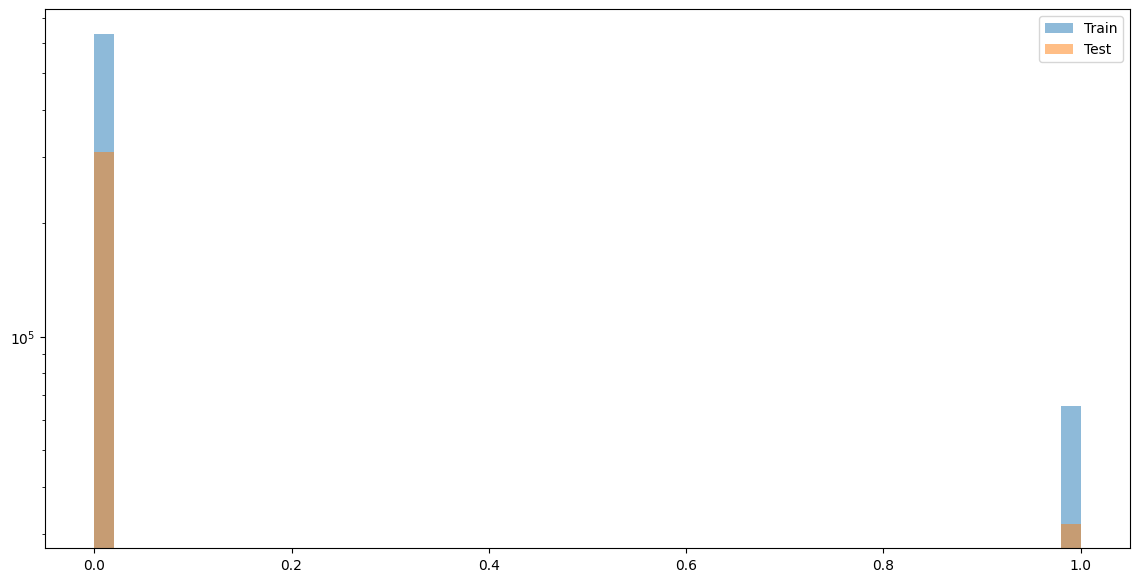

In [28]:
plt.figure(figsize=(14,7))
plt.hist(df_train[TARGET_NAME], bins=50, alpha=0.5, label='Train', log=True)
plt.hist(df_test[TARGET_NAME], bins=50, alpha=0.5, label='Test', log=True)
plt.legend()
plt.show()

In [29]:
print("df_train")
print('min:\t', df_train[TIME_TREND_FACTOR].min())
print('max:\t', df_train[TIME_TREND_FACTOR].max())
print(sorted(df_train['QUOTE_CLC_Year_week'].unique()))

df_train
min:	 2026-01-12 00:01:42
max:	 2026-03-22 23:59:12
['2026-03', '2026-04', '2026-05', '2026-06', '2026-07', '2026-08', '2026-09', '2026-10', '2026-11', '2026-12']


In [30]:
print("df_test")
print('min:\t', df_test[TIME_TREND_FACTOR].min())
print('max:\t', df_test[TIME_TREND_FACTOR].max())
print(sorted(df_test['QUOTE_CLC_Year_week'].unique()))

df_test
min:	 2026-03-23 00:00:20
max:	 2026-04-19 23:58:33
['2026-13', '2026-14', '2026-15', '2026-16']


### ---  UPLOAD SHORT LIST

In [31]:
if True:
    #FeatShortList = list(set(pd.read_csv(r"FSA_FeatTruncList02.csv", low_memory=False, sep=';', encoding = 'cp1251', decimal =',')['NAME']))
    FeatShortList = pd.read_csv(r"SelectedList.csv", low_memory=False, sep=';', encoding = 'cp1251', decimal =',')['NAME'].to_list()
    print(len(FeatShortList))

26


### Make Time-based cross validation using LAMA's TimeSeriesIterator

In [32]:
date_folds = [
    #np.datetime64('2026-01-05'),
    #np.datetime64('2026-01-12'),
    np.datetime64('2026-01-19'),
    np.datetime64('2026-01-26'),
    np.datetime64('2026-02-02'),
    np.datetime64('2026-02-09'),
    np.datetime64('2026-02-16'),
    np.datetime64('2026-02-23'),
    np.datetime64('2026-03-02'),
    np.datetime64('2026-03-09'),
    np.datetime64('2026-03-16'),
]


In [33]:
cv_iter = TimeSeriesIterator(
    df_train[TIME_TREND_FACTOR].astype("datetime64[ns]"),
    date_splits=date_folds,
    sorted_kfold=False,
)

#### --- check & visualize time-based split

Распределение по фолдам:
0    71589
1    68331
2    59796
3    67191
4    74133
5    65786
6    65978
7    66014
8    79390
9    83192
Name: count, dtype: int64

Фолд 0:
  Мин дата: 2026-01-12 00:01:42
  Макс дата: 2026-01-18 23:58:55
  Количество записей: 71589

Фолд 1:
  Мин дата: 2026-01-19 00:01:42
  Макс дата: 2026-01-25 23:59:47
  Количество записей: 68331

Фолд 2:
  Мин дата: 2026-01-26 00:02:05
  Макс дата: 2026-02-01 23:44:47
  Количество записей: 59796

Фолд 3:
  Мин дата: 2026-02-02 00:28:00
  Макс дата: 2026-02-08 23:58:59
  Количество записей: 67191

Фолд 4:
  Мин дата: 2026-02-09 00:02:01
  Макс дата: 2026-02-15 23:59:13
  Количество записей: 74133

Фолд 5:
  Мин дата: 2026-02-16 00:00:22
  Макс дата: 2026-02-22 23:57:50
  Количество записей: 65786

Фолд 6:
  Мин дата: 2026-02-23 00:00:52
  Макс дата: 2026-03-01 23:58:10
  Количество записей: 65978

Фолд 7:
  Мин дата: 2026-03-02 00:00:18
  Макс дата: 2026-03-08 23:58:57
  Количество записей: 66014

Фолд 8:
  Мин дата: 20

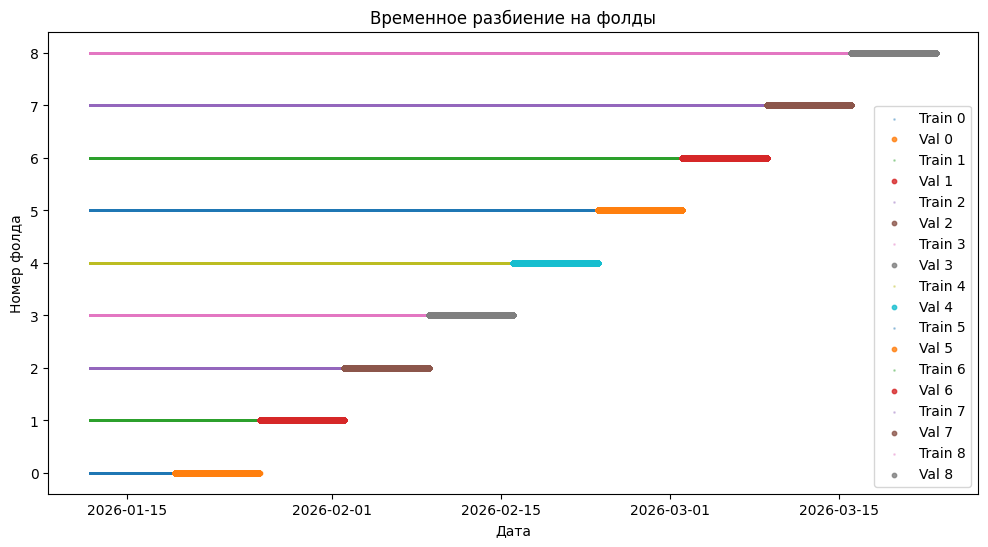

In [34]:
# # Проверьте распределение фолдов  
print("Распределение по фолдам:")  
print(pd.Series(cv_iter.folds).value_counts().sort_index())  
  
# # Проверьте, какие даты попали в каждый фолд  
for fold_num in range(cv_iter.n_splits):  
    fold_dates = df_train['TECHDATA_RUNDATE'][cv_iter.folds == fold_num]  
    print(f"\nФолд {fold_num}:")  
    print(f"  Мин дата: {fold_dates.min()}")  
    print(f"  Макс дата: {fold_dates.max()}")  
    print(f"  Количество записей: {len(fold_dates)}")

# # Проверьте каждый фолд  
for i in range(len(cv_iter)):  
    train_idx, val_idx = cv_iter[i]  
      
    print(f"\n=== Фолд {i} ===")  
    print(f"Train размер: {len(train_idx)}")  
    print(f"Validation размер: {len(val_idx)}")  
      
    # Проверьте временной порядок  
    train_dates = df_train['TECHDATA_RUNDATE'].iloc[train_idx]  
    val_dates = df_train['TECHDATA_RUNDATE'].iloc[val_idx]  
      
    print(f"Train даты: {train_dates.min()} - {train_dates.max()}")  
    print(f"Val даты: {val_dates.min()} - {val_dates.max()}")  
      
    # ВАЖНО: для sorted_kfold=False train должен быть СТРОГО раньше validation  
    if train_dates.max() >= val_dates.min():  
        print("⚠️ ПРЕДУПРЕЖДЕНИЕ: Обнаружена утечка данных из будущего!")  
    else:  
        print("✓ OK: Train данные раньше validation данных")

import matplotlib.pyplot as plt  
  
# # Создайте визуализацию  
fig, ax = plt.subplots(figsize=(12, 6))  
  
for i in range(len(cv_iter)):  
    train_idx, val_idx = cv_iter[i]  
      
    # Отметьте train и validation на временной оси  
    ax.scatter(df_train['TECHDATA_RUNDATE'].iloc[train_idx],   
               [i] * len(train_idx),   
               alpha=0.3, label=f'Train {i}', s=1)  
    ax.scatter(df_train['TECHDATA_RUNDATE'].iloc[val_idx],   
               [i] * len(val_idx),   
               alpha=0.8, label=f'Val {i}', s=10)  
  
ax.set_ylabel('Номер фолда')  
ax.set_xlabel('Дата')  
ax.set_title('Временное разбиение на фолды')  
plt.legend()  
plt.show()


# 02. LAMA train model

## Setup for LightAutoML

Здесь мы устанавливаем некоторые параметры для использования в ноутбуке:

- **N_THREADS** - количество vCPU для создания модели LightAutoML
- **N_FOLDS** - количество фолдов во внутренней кросс-валидации LightAutoML  
- **RANDOM_STATE** - случайное salt для лучшей воспроизводимости
- **TEST_SIZE** - размер тестовой части данных
- **TIMEOUT** - лимит в секундах для обучения модели
- **TARGET_NAME** - имя целевой колонки в датасете

In [35]:
import os

num_threads = os.cpu_count()
print(f"Количество доступных потоков: {num_threads}")
import multiprocessing

num_threads = multiprocessing.cpu_count()
print(f"Количество доступных потоков: {num_threads}")


Количество доступных потоков: 64
Количество доступных потоков: 64


In [36]:
N_THREADS = 30
N_FOLDS = 10
RANDOM_STATE = 28
TIMEOUT = 120*60*60

np.random.seed(RANDOM_STATE)
torch.set_num_threads(N_THREADS)

## BINARY

Можно также указать дополнительные роли признаков:

- `numeric` — числовой признак
- `category` — категориальный признак
- `text` — текстовые данные
- `datetime` — признаки с датой и временем
- `date` — признаки только с датой
- `group` — признаки, по которым данные можно разделить на группы (используется для групповой кросс-валидации, чтобы одна группа не попадала одновременно в обучение и тест)
- `drop` — признаки, которые нужно исключить, они не будут использоваться при построении модели
- `weights` — веса объектов для функции потерь и метрик
- `path` — пути к файлам изображений (для задач компьютерного зрения)
- `treatment` — принадлежность объекта к группе в uplift-задачах: лечение или

### --- fit predict

In [37]:
#TARGET_NAME = 'Response'  # Rename to match the target column in dataset 
roles = {
    'target': TARGET_NAME,
    'drop': [col for col in df_train.columns if (col not in FeatShortList) and (col not in [TARGET_NAME, WEIGHT_NAME])] # Exclude non-tag columns                
}
task = Task(name='binary')

In [38]:
RD = ReportDeco(output_path = 'TR_SRVN_model_report')

automl_rd = RD(
    TabularAutoML(
        task = task,
        timeout = TIMEOUT,
        cpu_limit = N_THREADS,
        general_params = {
           'use_algos': [['linear_l2', 'lgb', 'lgb_tuned', 'cb','cb_tuned', 'xgb', 'xgb_tuned']],
        #     'nested_cv': False,  
        #     'skip_conn': True,  # With skip_conn=True (default), original features are also passed to Level 1
        #     'return_all_predictions': False,  # True to get all Level N predictions
        #     'weighted_blender_max_nonzero_coef': 0.05  # Drop models with weight < 0.05
        },
        # # To avoid data leakage for Level 1 models in LightAutoML, the system uses out-of-fold (OOF) predictions from Level 0 models during cross-validation
  
        selection_params = {
            'fit_on_holdout': False,
            'mode': 1,
            #'cutoff': 0.01,
            #'importance_type': 'permutation',
            'feature_group_size': 1,
            'select_algos': ['linear_l2', 'gbm'],
            #'max_features_cnt_in_result': 25
        },
        
        tuning_params= {
            'fit_on_holdout': False,
            'max_tuning_time': 60*60*2
        },
        reader_params = {
            #'advanced_roles': True, #True by Default
            'n_jobs': N_THREADS, 
            'cv_iter': cv_iter,
            #'cv': N_FOLDS,
            'random_state': RANDOM_STATE 
        },
        # # ------------ set up for Poisson params
        # lgb_params={
        #     'default_params': {
        #         'objective': 'poisson',  
        #         'metric': 'poisson'
        #     },
        #     'freeze_defaults': True
        # },

        # cb_params={
        #     'default_params': {
        #         'loss_function': 'Poisson',  
        #         'eval_metric': 'Poisson'
        #     },
        #     'freeze_defaults': True
        # },

        # xgb_params={
        #     'default_params': {
        #         'objective': 'count:poisson',  
        #         'eval_metric': 'poisson-nloglik'
        #     },
        #     'freeze_defaults': True
        # },
        
    )

)

In [39]:
%%time 
oof_pred_binary = automl_rd.fit_predict(df_train, roles = roles, verbose = 4, cv_iter=cv_iter)

[10:24:32] Stdout logging level is DEBUG.
[10:24:32] Copying TaskTimer may affect the parent PipelineTimer, so copy will create new unlimited TaskTimer
[10:24:32] Task: binary

[10:24:32] Start automl preset with listed constraints:
[10:24:32] - time: 432000.00 seconds
[10:24:32] - CPU: 30 cores
[10:24:32] - memory: 16 GB

[10:24:32] Train data shape: (701400, 145)

[10:24:42] Feats was rejected during automatic roles guess: []
[10:24:42] Layer 1 train process start. Time left 431990.12 secs
[10:24:42] Start fitting Selector_LightGBM ...
[10:24:42] Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 244, 'feature_fraction': 1, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 1, 'reg_lambda': 0.0, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 30, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 2000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100}
[10:24:42] ===== Start working with 

2026-07-17 10:27:13,609 - INFO - A new study created in memory with name: no-name-bcd25d87-1de9-4eca-9321-7831bfc51b1c


[10:27:13] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...
[10:27:13] Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 244, 'feature_fraction': 0.6872700594236812, 'bagging_fraction': 0.8659969709057025, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 30, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 2000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100, 'min_sum_hessian_in_leaf': 0.24810409748678125}
[10:27:13] ===== Start working with fold 0 for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM =====
[10:27:13] Training until validation scores don't improve for 100 rounds
[10:27:15] [100]	valid's auc: 0.935384
[10:27:16] [200]	valid's auc: 0.935461
[10:27:18] Early stopping, best iteration is:
[184]	valid's auc: 0.935636
[10:27:18] ===== Start working with fold 1 for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ====

2026-07-17 10:28:19,982 - INFO - Trial 0 finished with value: 0.9393658549798667 and parameters: {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 0.9393658549798667.


[10:28:19] Trial 1 with hyperparameters {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07} scored 0.9393658549798667 in 0:01:06.371535
[10:28:19] Start fitting Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM ...
[10:28:19] Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 223, 'feature_fraction': 0.5290418060840998, 'bagging_fraction': 0.8005575058716043, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 1.5320059381854043e-08, 'reg_lambda': 5.360294728728285, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 30, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 2000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100, 'min_sum_hessian_in_leaf': 0.679657809075816}
[10:28:20] ===== Start working with fold 0 for Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM =====
[10:28:20]

...

[16:28:21] Trial 13 with hyperparameters {'colsample_bytree': 0.6, 'subsample': 0.6, 'max_depth': 5, 'learning_rate': 0.02, 'min_child_weight': 65, 'reg_alpha': 0.16147487621964793, 'reg_lambda': 2.3428536633786012} scored 0.9409347312968037 in 0:08:16.142538
[16:28:21] Start fitting Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost ...
[16:28:21] Training params: {'n_estimators': 3000, 'early_stopping_rounds': 100, 'seed': 42, 'verbose_eval': 100, 'nthread': 30, 'colsample_bytree': 0.8, 'subsample': 0.4, 'max_depth': 7, 'learning_rate': 0.01, 'min_child_weight': 11, 'reg_alpha': 6.197986697947777, 'reg_lambda': 3.1293674313292352}
[16:28:21] ===== Start working with fold 0 for Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost =====
[16:28:22] [0]	valid-auc:0.89770
[16:28:23] [100]	valid-auc:0.92809
[16:28:24] [200]	valid-auc:0.93077
[16:28:25] [300]	valid-auc:0.93242
[16:28:27] [400]	valid-auc:0.93389
[16:28:28] [500]	valid-auc:0.93500
[16:28:30] [600]	valid-auc:0.93579
[16:28:31] [700]	valid-auc:0.93641
[16:28:32] [8

2026-07-17 16:36:56,894 - INFO - Trial 13 finished with value: 0.9407451357730674 and parameters: {'colsample_bytree': 0.8, 'subsample': 0.4, 'max_depth': 7, 'learning_rate': 0.01, 'min_child_weight': 11, 'reg_alpha': 6.197986697947777, 'reg_lambda': 3.1293674313292352}. Best is trial 10 with value: 0.9411155515784375.


[16:36:56] Trial 14 with hyperparameters {'colsample_bytree': 0.8, 'subsample': 0.4, 'max_depth': 7, 'learning_rate': 0.01, 'min_child_weight': 11, 'reg_alpha': 6.197986697947777, 'reg_lambda': 3.1293674313292352} scored 0.9407451357730674 in 0:08:35.159255
[16:36:56] Start fitting Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost ...
[16:36:56] Training params: {'n_estimators': 3000, 'early_stopping_rounds': 100, 'seed': 42, 'verbose_eval': 100, 'nthread': 30, 'colsample_bytree': 0.7, 'subsample': 0.6, 'max_depth': 7, 'learning_rate': 0.018, 'min_child_weight': 115, 'reg_alpha': 0.16671229135810722, 'reg_lambda': 0.09735125945191662}
[16:36:56] ===== Start working with fold 0 for Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost =====
[16:36:57] [0]	valid-auc:0.90386
[16:36:58] [100]	valid-auc:0.92856
[16:37:00] [200]	valid-auc:0.93258
[16:37:01] [300]	valid-auc:0.93475
[16:37:03] [400]	valid-auc:0.93589
[16:37:04] [500]	valid-auc:0.93653
[16:37:05] [600]	valid-auc:0.93697
[16:37:07] [700]	valid-auc:0.93720
[16:37:08]

2026-07-17 16:44:14,985 - INFO - Trial 14 finished with value: 0.9407703930120982 and parameters: {'colsample_bytree': 0.7, 'subsample': 0.6, 'max_depth': 7, 'learning_rate': 0.018, 'min_child_weight': 115, 'reg_alpha': 0.16671229135810722, 'reg_lambda': 0.09735125945191662}. Best is trial 10 with value: 0.9411155515784375.


[16:44:14] Trial 15 with hyperparameters {'colsample_bytree': 0.7, 'subsample': 0.6, 'max_depth': 7, 'learning_rate': 0.018, 'min_child_weight': 115, 'reg_alpha': 0.16671229135810722, 'reg_lambda': 0.09735125945191662} scored 0.9407703930120982 in 0:07:18.077501
[16:44:14] Hyperparameters optimization for Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost completed
[16:44:14] The set of hyperparameters {'colsample_bytree': 0.6, 'subsample': 0.6, 'max_depth': 7, 'learning_rate': 0.01, 'min_child_weight': 5, 'reg_alpha': 4.2722748162268, 'reg_lambda': 7.801286500308009}
 achieve 0.9411 auc
[16:44:14] Start fitting Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost ...
[16:44:14] Training params: {'n_estimators': 3000, 'early_stopping_rounds': 100, 'seed': 42, 'verbose_eval': 100, 'nthread': 30, 'colsample_bytree': 0.6, 'subsample': 0.6, 'max_depth': 7, 'learning_rate': 0.01, 'min_child_weight': 5, 'reg_alpha': 4.2722748162268, 'reg_lambda': 7.801286500308009}
[16:44:15] ===== Start working with fold 0 for Lvl_0_Pipe_1_Mod_

#### --- model structure

In [40]:
print(automl_rd.model.create_model_str_desc())

Final prediction for new objects (level 0) = 
	 0.09344 * (9 averaged models Lvl_0_Pipe_1_Mod_0_LightGBM) +
	 0.34794 * (9 averaged models Lvl_0_Pipe_1_Mod_1_Tuned_LightGBM) +
	 0.15668 * (9 averaged models Lvl_0_Pipe_1_Mod_2_CatBoost) +
	 0.17395 * (9 averaged models Lvl_0_Pipe_1_Mod_3_Tuned_CatBoost) +
	 0.07033 * (9 averaged models Lvl_0_Pipe_1_Mod_4_XGBoost) +
	 0.15765 * (9 averaged models Lvl_0_Pipe_1_Mod_5_Tuned_XGBoost) 


#### --- save models in pkl

In [41]:
import joblib
joblib.dump(automl_rd.model, "TR_SRVN_model.pkl")

['TR_SRVN_model.pkl']

In [42]:
import pickle
import lzma

with lzma.open(r"TR_SRVN_model_compressed.xz", "wb", preset=9) as f:
    pickle.dump(automl_rd.model, f, protocol=pickle.HIGHEST_PROTOCOL)

#### --- make predictions

In [43]:
# Call predict to add to html report OOT prediction
test_binary_prediction = automl_rd.predict(df_test)

In [44]:
# Save pred to test db as 'Pred_fin_LAMA'
df_test['Pred_fin_LAMA'] = test_binary_prediction.data[:, 0]

In [45]:
# score by final model
train_db_binary_prediction = automl_rd.model.predict(df_train)

In [46]:
# Save pred final to train db as 'Pred_fin_LAMA'
df_train['Pred_fin_LAMA'] = train_db_binary_prediction.data[:, 0]

In [47]:
# Save pred OOF to train db as 'Pred_oof_LAMA' and CV fold
df_train['Pred_oof_LAMA'] = oof_pred_binary.data[:, 0]
df_train['Pred_oof_FOLDS'] = oof_pred_binary.folds

In [48]:
print(df_train['Pred_fin_LAMA'].isna().sum())
print(df_train['Pred_oof_LAMA'].isna().sum())
print(df_test['Pred_fin_LAMA'].isna().sum())

0
71589
0


In [49]:
df_train_oof = df_train.dropna(subset=['Pred_oof_LAMA'])

In [50]:
print(df_train_oof['Pred_oof_LAMA'].isna().sum())

0


In [51]:
print(f'TRAIN ROCAUC:{roc_auc_score(df_train[TARGET_NAME].values, train_db_binary_prediction.data[:,0])}')
print(f'OOF ROCAUC:{roc_auc_score(df_train_oof[TARGET_NAME].values,df_train_oof['Pred_oof_LAMA'].values)}')
print(f'OOT ROCAUC:{roc_auc_score(df_test[TARGET_NAME].values, test_binary_prediction.data[:,0])}')

TRAIN ROCAUC:0.9486126144863658
OOF ROCAUC:0.9414645763948869
OOT ROCAUC:0.9394997965035814


In [52]:
print(f'TRAIN GINI:{2*roc_auc_score(df_train[TARGET_NAME].values, train_db_binary_prediction.data[:,0])-1}')
print(f'OOF GINI:{2*roc_auc_score(df_train_oof[TARGET_NAME].values, df_train_oof['Pred_oof_LAMA'].values)-1}')
print(f'OOT GINI:{2*roc_auc_score(df_test[TARGET_NAME].values, test_binary_prediction.data[:,0])-1}')

TRAIN GINI:0.8972252289727316
OOF GINI:0.8829291527897738
OOT GINI:0.8789995930071628


### -- Extraction

In [53]:
if True:
    # -- extract train db
    df_train[FeatShortList + [TIME_TREND_FACTOR, WEIGHT_NAME, TARGET_NAME, 'Pred_fin_LAMA', 'Pred_oof_LAMA','Pred_oof_FOLDS']].to_csv("df_train_scored.csv", sep=';', encoding = 'cp1251', decimal =',')
    # -- extract test db
    df_test[FeatShortList + [TIME_TREND_FACTOR, WEIGHT_NAME, TARGET_NAME, 'Pred_fin_LAMA']].to_csv("df_oot_scored.csv", sep=';', encoding = 'cp1251', decimal =',')

### --- Weighted Gini normalized

In [54]:
print("GINI TRAIN:\t", lorenz_gini_and_normalized(df_train, WEIGHT_NAME, TARGET_NAME, 'Pred_fin_LAMA'))
print("GINI OOF:\t", lorenz_gini_and_normalized(df_train_oof, WEIGHT_NAME, TARGET_NAME, 'Pred_oof_LAMA'))
print("GINI OOT:\t", lorenz_gini_and_normalized(df_test, WEIGHT_NAME, TARGET_NAME, 'Pred_fin_LAMA'))

GINI TRAIN:	 (0.8134688569720046, 0.8972252286340305)
GINI OOF:	 (0.8027140984394328, 0.882929152114714)
GINI OOT:	 (0.796656445731494, 0.8789995927912813)


In [55]:
# Создаем словарь для сохранения результатов оценки 
outout_dict = {'Segment' : [], 'GINI_Lorenz' : [], 'GINI_Normalized' : []}

In [56]:
# -- manual filling
## train
gini, gini_norm = lorenz_gini_and_normalized(df_train, WEIGHT_NAME, TARGET_NAME, 'Pred_fin_LAMA')
outout_dict['Segment'].append("TRAIN")
outout_dict['GINI_Lorenz'].append(gini)
outout_dict['GINI_Normalized'].append(gini_norm)

## oof
gini, gini_norm = lorenz_gini_and_normalized(df_train_oof, WEIGHT_NAME, TARGET_NAME, 'Pred_oof_LAMA')
outout_dict['Segment'].append("OOF")
outout_dict['GINI_Lorenz'].append(gini)
outout_dict['GINI_Normalized'].append(gini_norm)

## oot
gini, gini_norm = lorenz_gini_and_normalized(df_test, WEIGHT_NAME, TARGET_NAME, 'Pred_fin_LAMA')
outout_dict['Segment'].append("OOT")
outout_dict['GINI_Lorenz'].append(gini)
outout_dict['GINI_Normalized'].append(gini_norm)

In [57]:
gini_df = pd.DataFrame(outout_dict)

In [58]:
gini_df

,Segment,GINI_Lorenz,GINI_Normalized
0,TRAIN,0.813469,0.897225
1,OOF,0.802714,0.882929
2,OOT,0.796656,0.879000


In [59]:
gini_df.to_csv("gini_df.csv", sep=';', encoding = 'cp1251', decimal =',')

In [60]:
model_task_metric_name = 'GINI' if task.metric_name is None else task.metric_name

In [61]:
model_cv_folds = automl_rd.model.reader.params['cv_iter'].n_splits - 1

In [62]:
SummaryStats_weighted_tbl = pd.DataFrame({
    'MODE': [automl_rd.model.selection_params['mode']],
    'FEATURE_GROUP_SIZE': [automl_rd.model.selection_params['feature_group_size']],
    'MAX_TUNING_TIME_M': [automl_rd.model.tuning_params['max_tuning_time']/60],
    'METRIC': [model_task_metric_name],
    'CV_FOLDS': [model_cv_folds],
    'TEST_SIZE': [df_test.shape[0] / (df_train.shape[0] + df_test.shape[0])],
    'USED_FEATS': len(sorted(automl_rd.model.collect_used_feats())),
    'TRAIN_GINI': [gini_df['GINI_Normalized'][0]],
    'OOF_GINI': [gini_df['GINI_Normalized'][1]],
    'OOT_GINI': [gini_df['GINI_Normalized'][2]],
    'MODEL_STRUCTURE' : [automl_rd.model.create_model_str_desc()]
})
SummaryStats_weighted_tbl.to_csv('SummaryStats_weighted_tbl.csv', sep=';', encoding = 'cp1251', decimal =',')
SummaryStats_weighted_tbl

,MODE,FEATURE_GROUP_SIZE,MAX_TUNING_TIME_M,METRIC,CV_FOLDS,TEST_SIZE,USED_FEATS,TRAIN_GINI,OOF_GINI,OOT_GINI,MODEL_STRUCTURE
0,1,1,120.0,auc,9,0.326597,26,0.897225,0.882929,0.879,Final prediction for new objects (level 0) = \...


### --- GINI dynamic

#### -------- GINI TRAIN

In [63]:
oot_df1 = pd.DataFrame(df_train[TARGET_NAME])
oot_df1['FIN_pred'] = pd.DataFrame(df_train['Pred_fin_LAMA'])
oot_df1[TIME_TREND_FACTOR] = df_train[TIME_TREND_FACTOR]
oot_df1[WEIGHT_NAME] = df_train[WEIGHT_NAME]

📊 Построен график для 10 периодов
📈 Gini Norm: 0.89723
📉 Мин Gini: 0.88432
📈 Макс Gini: 0.90827
📊 Среднее кол-во наблюдений: 70140


(<Figure size 1400x800 with 2 Axes>,
 <Axes: title={'center': 'WEIGHTED GINI TREND TRAIN'}, xlabel='Период', ylabel='Gini'>)

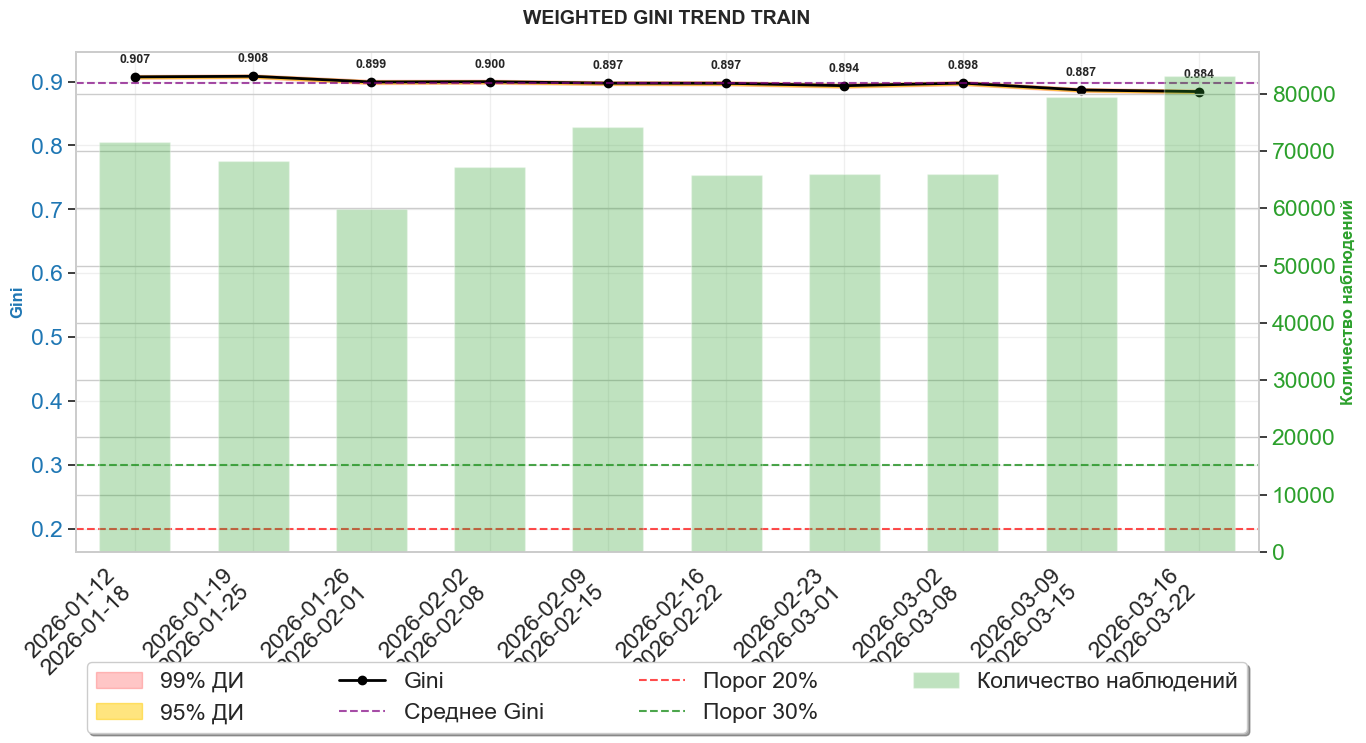

In [64]:
plot_gini_dynamics_2(oot_df1, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W", title = "WEIGHTED GINI TREND TRAIN")

📊 Построен график для 10 периодов
📈 Gini: 0.897
📉 Мин Gini: 0.884
📈 Макс Gini: 0.908
📊 Среднее кол-во наблюдений: 70140


(<Figure size 1400x800 with 2 Axes>,
 <Axes: title={'center': 'GINI TREND TRAIN'}, xlabel='Период', ylabel='Gini'>)

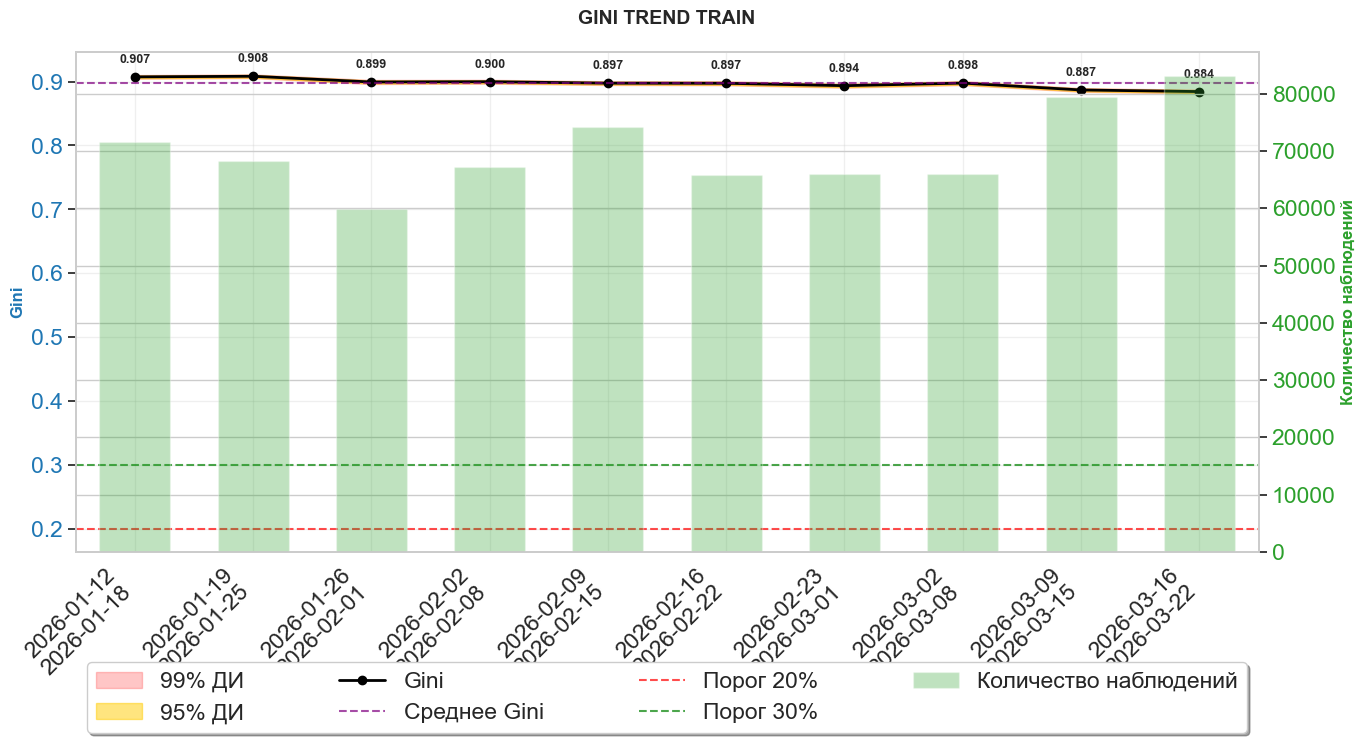

In [65]:
plot_gini_dynamics(oot_df1, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W", title = "GINI TREND TRAIN")

##### --------- save to csv

In [66]:
gini_time_trend_train = calc_gini_dynamics_2(oot_df1, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "M")
gini_time_trend_train.to_csv('gini_time_trend_train_m.csv', sep=';', encoding = 'cp1251', decimal =',')

In [67]:
gini_time_trend_train_q = calc_gini_dynamics_2(oot_df1, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W")
gini_time_trend_train_q.to_csv('gini_time_trend_train_w.csv', sep=';', encoding = 'cp1251', decimal =',')

#### -------- GINI OOF

In [68]:
oot_df1 = pd.DataFrame(df_train_oof[TARGET_NAME])
oot_df1['FIN_pred'] = pd.DataFrame(df_train_oof['Pred_fin_LAMA'])
oot_df1[TIME_TREND_FACTOR] = df_train_oof[TIME_TREND_FACTOR]
oot_df1[WEIGHT_NAME] = df_train_oof[WEIGHT_NAME]

📊 Построен график для 9 периодов
📈 Gini Norm: 0.89568
📉 Мин Gini: 0.88432
📈 Макс Gini: 0.90827
📊 Среднее кол-во наблюдений: 69979


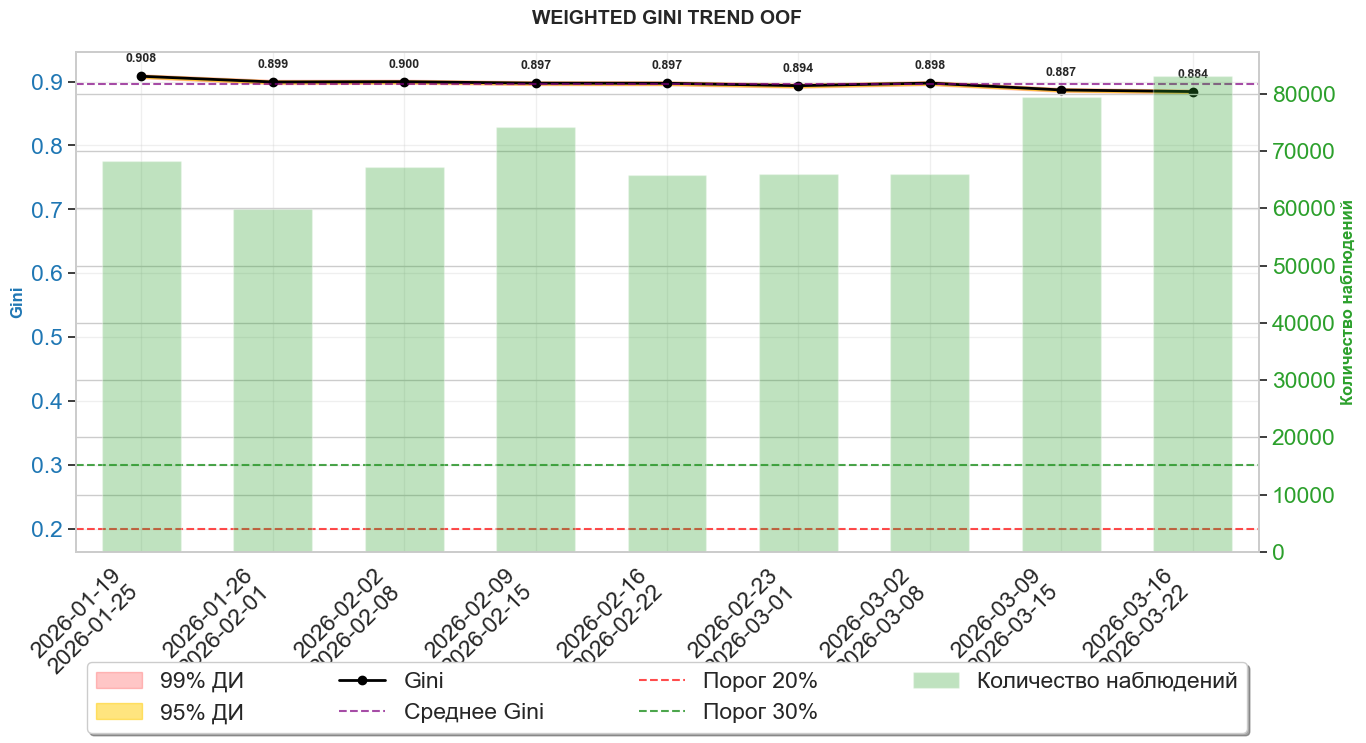

In [69]:
plot_gini_dynamics_2(oot_df1, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W", title = "WEIGHTED GINI TREND OOF")

gini_time_trend_oof = calc_gini_dynamics_2(oot_df1, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "M")
gini_time_trend_oof.to_csv('gini_time_trend_oof_m.csv', sep=';', encoding = 'cp1251', decimal =',')

gini_time_trend_oof_q = calc_gini_dynamics_2(oot_df1, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W")
gini_time_trend_oof_q.to_csv('gini_time_trend_oof_w.csv', sep=';', encoding = 'cp1251', decimal =',')

📊 Построен график для 9 периодов
📈 Gini: 0.896
📉 Мин Gini: 0.884
📈 Макс Gini: 0.908
📊 Среднее кол-во наблюдений: 69979


(<Figure size 1400x800 with 2 Axes>,
 <Axes: title={'center': 'GINI TREND OOF'}, xlabel='Период', ylabel='Gini'>)

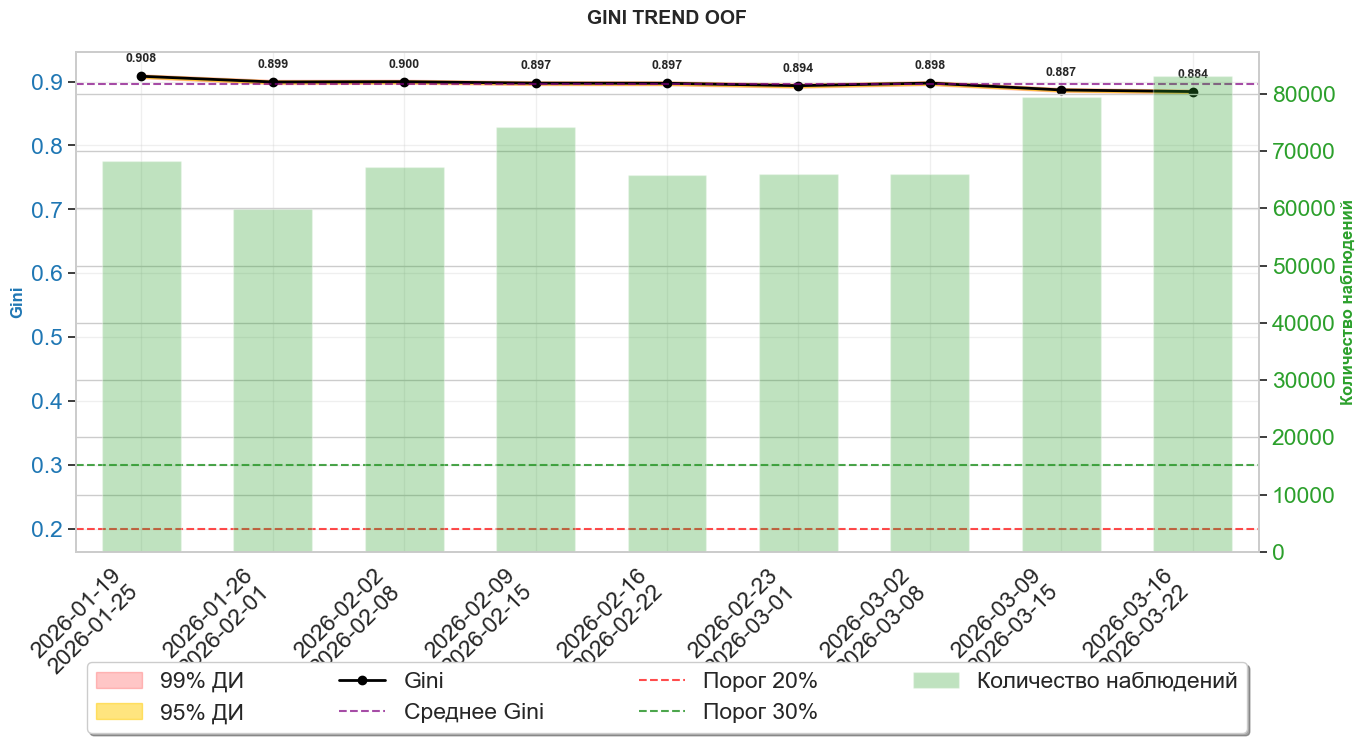

In [70]:
plot_gini_dynamics(oot_df1, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W", title = "GINI TREND OOF")

#### --------➡️ GINI OOT

📊 Построен график для 4 периодов
📈 Gini Norm: 0.87900
📉 Мин Gini: 0.87249
📈 Макс Gini: 0.88533
📊 Среднее кол-во наблюдений: 85044


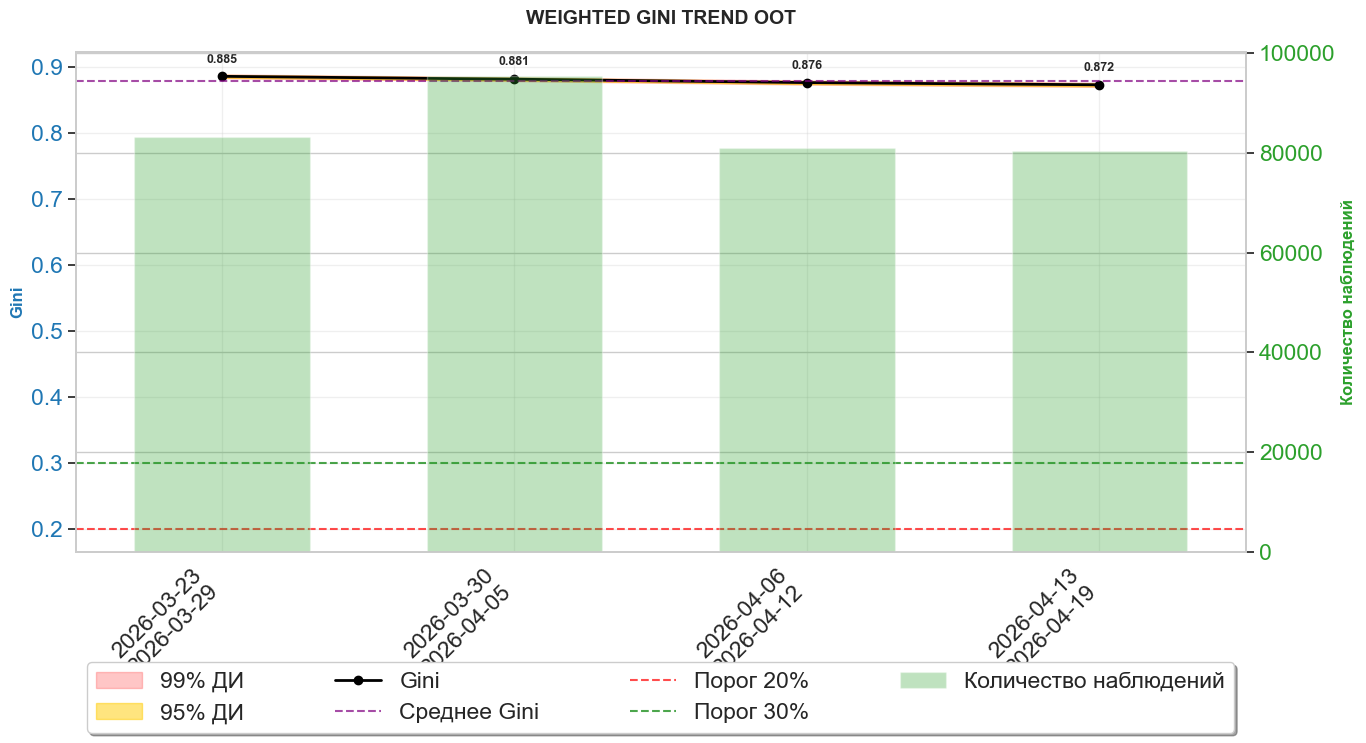

In [71]:
oot_df2 = pd.DataFrame(df_test[TARGET_NAME])
oot_df2['FIN_pred'] = pd.DataFrame(df_test['Pred_fin_LAMA'])
oot_df2[TIME_TREND_FACTOR] = df_test[TIME_TREND_FACTOR]
oot_df2[WEIGHT_NAME] = df_test[WEIGHT_NAME]

plot_gini_dynamics_2(oot_df2, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W", title = "WEIGHTED GINI TREND OOT")

gini_time_trend_test = calc_gini_dynamics_2(oot_df2, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "M")
gini_time_trend_test.to_csv('gini_time_trend_oot_m.csv', sep=';', encoding = 'cp1251', decimal =',')

gini_time_trend_test_q = calc_gini_dynamics_2(oot_df2, WEIGHT_NAME, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W")
gini_time_trend_test_q.to_csv('gini_time_trend_oot_w.csv', sep=';', encoding = 'cp1251', decimal =',')

📊 Построен график для 4 периодов
📈 Gini: 0.879
📉 Мин Gini: 0.872
📈 Макс Gini: 0.885
📊 Среднее кол-во наблюдений: 85044


(<Figure size 1400x800 with 2 Axes>,
 <Axes: title={'center': 'GINI TREND OOT'}, xlabel='Период', ylabel='Gini'>)

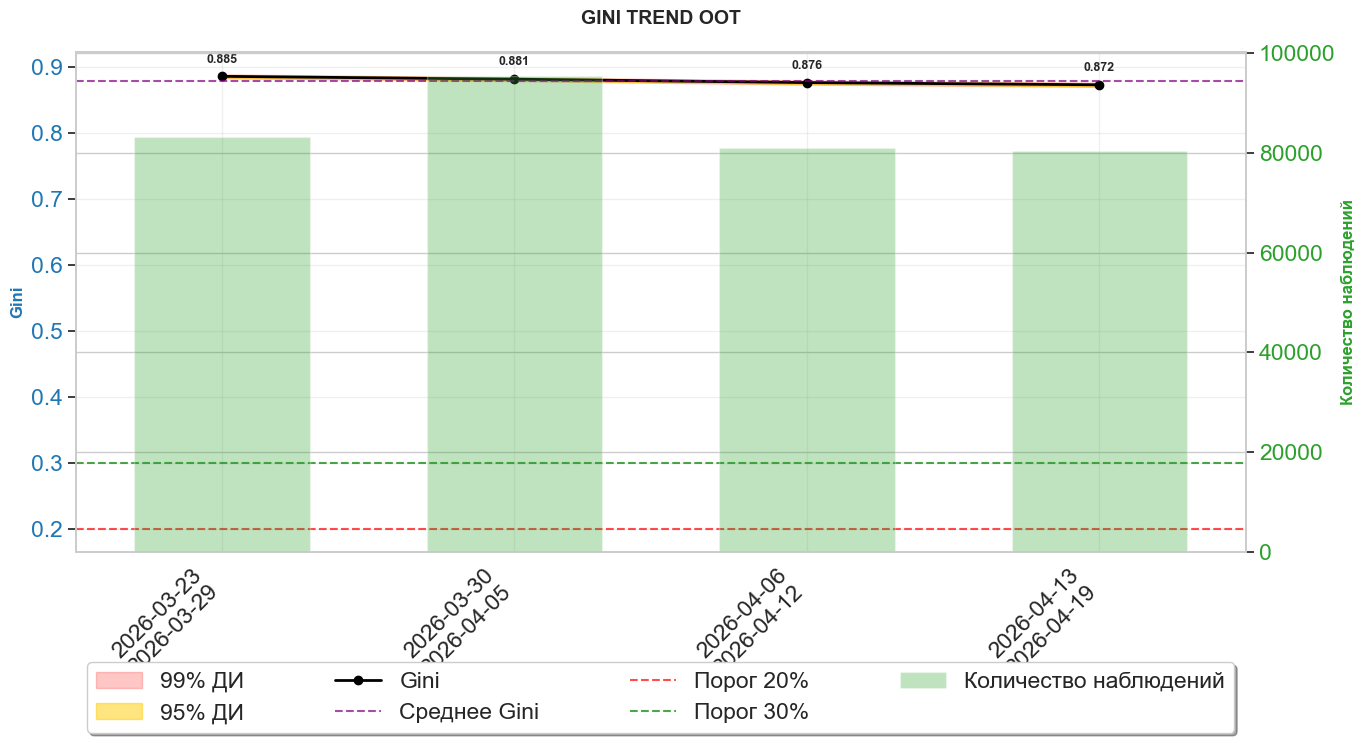

In [72]:
plot_gini_dynamics(oot_df2, TARGET_NAME, "FIN_pred", TIME_TREND_FACTOR, freq = "W", title = "GINI TREND OOT")

### --- Make and save Feature Importance (fast and permutation)

In [73]:
%%time
# Selected feats
selected_feats_binary = sorted(automl_rd.model.collect_used_feats())
print('LightAutoML has selected {} feats!'.format(len(selected_feats_binary)))
for i in selected_feats_binary:
    print(i)

LightAutoML has selected 26 feats!
CB_PREM_COEF_KBM_Lookup
CI_201_005d_num
HAVE_QUOTES_ON_OTHER_POS_BEFORE_MP
HAVE_QUOTES_ON_OTHER_POS_BEFORE_OTHER
HT_MKT_DTP_PROB_py
IC_CONV_ENCODING_PREV1_A5
MKT_CURR_MATCH_DRIVERS_COUNT_DIFFTO_PREV_py
MKT_DTP_SCORE_COMBINED_PROB_py
PEOPLE_EXP_WORST
POLICY_OSAGO_CHAIN_NUMBER
POL_DAYS_BEETWEEN_NACH
POL_days_between_prev_curr_pol_py
PREMIUM_SBS_Offered
PREMIUM_SBS_Rank_band
PREMIUM_SBS_diff_to_Competitors_Average_weighted_abs_num
PREMIUM_SBS_diff_to_Competitors_Incoming_abs_num
PREMIUM_SBS_diff_to_Competitors_Incoming_per_num
PREMIUM_SBS_diff_to_Competitors_MaxValue_abs_num
PREMIUM_SBS_diff_to_Competitors_MaxValue_per_num
PREMIUM_SBS_diff_to_Competitors_MinValue_abs_num
QUOTE_PRIOR_YEARS_ISSUED_AT_POS
REGION_BOOL_MSK_MO
REGION_MKT_ENCODING_ADM08_A6_py
RULE3_AMOUNT_LDU_py
VEHICLE_CATALOG_PRICE_Avg
VEHICLE_OWNERSHIP_multiplicity_num
CPU times: total: 0 ns
Wall time: 0 ns


CPU times: total: 62.5 ms
Wall time: 55.4 ms


<Axes: xlabel='Feature'>

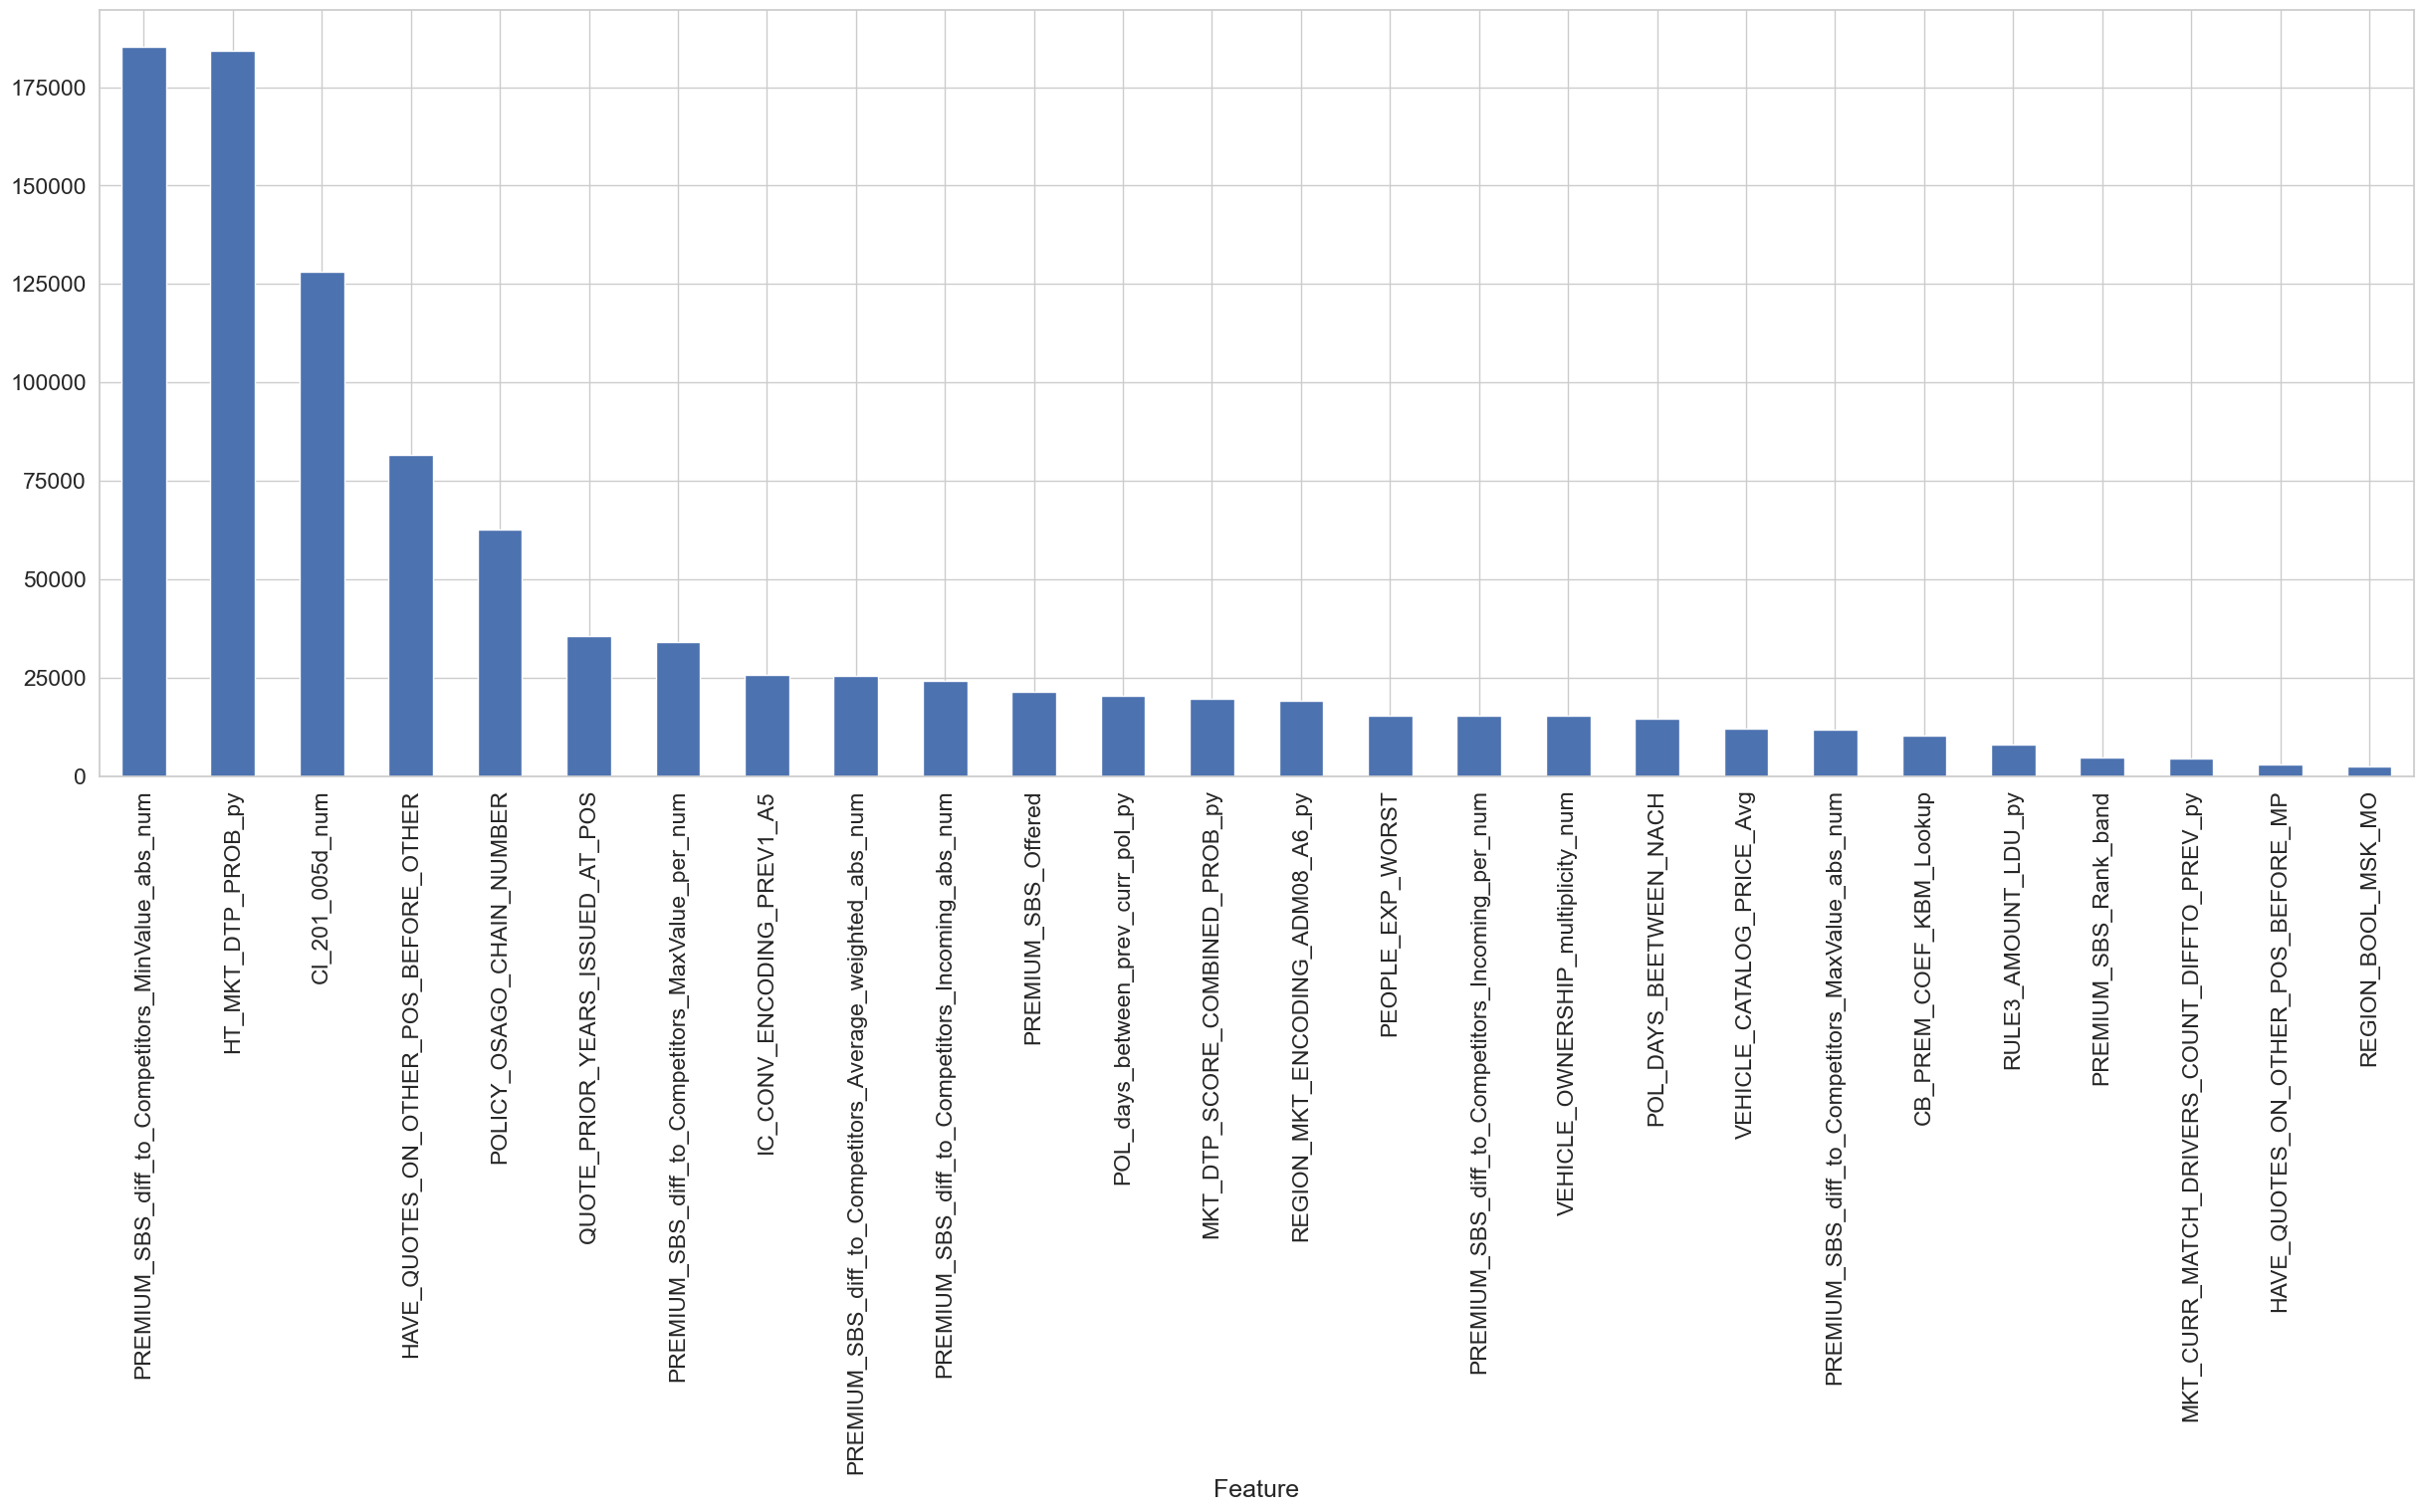

In [74]:
%%time
# Fast feature importances calculation
fast_fi = automl_rd.model.get_feature_scores('fast')
fast_fi.set_index('Feature')['Importance'].plot.bar(figsize = (30, 10), grid = True)

In [75]:
fast_fi.to_csv('df_train_FI_fast.csv', sep=';', encoding = 'cp1251', decimal =',')

In [76]:
for feature in fast_fi['Feature'].to_list():
    importance_run = fast_fi.loc[fast_fi['Feature'] == feature].iloc[0]['Importance']
    rank_run = fast_fi.loc[fast_fi['Feature'] == feature].index.values[0] + 1

    if "TAG_" in feature:
        print("Rank: ", rank_run, "\t", feature, "\t", tags_name_map.get(feature), "\t\t Importance:", importance_run)
    else:
        print("Rank: ", rank_run, "\t", feature, "\t", "\t\t Importance:", importance_run)

Rank:  1 	 PREMIUM_SBS_diff_to_Competitors_MinValue_abs_num 	 		 Importance: 185369.95541890463
Rank:  2 	 HT_MKT_DTP_PROB_py 	 		 Importance: 184135.36932716105
Rank:  3 	 CI_201_005d_num 	 		 Importance: 128154.90911698341
Rank:  4 	 HAVE_QUOTES_ON_OTHER_POS_BEFORE_OTHER 	 		 Importance: 81692.77081698841
Rank:  5 	 POLICY_OSAGO_CHAIN_NUMBER 	 		 Importance: 62609.640326062836
Rank:  6 	 QUOTE_PRIOR_YEARS_ISSUED_AT_POS 	 		 Importance: 35671.07709467411
Rank:  7 	 PREMIUM_SBS_diff_to_Competitors_MaxValue_per_num 	 		 Importance: 34098.82776011361
Rank:  8 	 IC_CONV_ENCODING_PREV1_A5 	 		 Importance: 25719.35363226467
Rank:  9 	 PREMIUM_SBS_diff_to_Competitors_Average_weighted_abs_num 	 		 Importance: 25487.865048130352
Rank:  10 	 PREMIUM_SBS_diff_to_Competitors_Incoming_abs_num 	 		 Importance: 24145.015829814805
Rank:  11 	 PREMIUM_SBS_Offered 	 		 Importance: 21521.89030122757
Rank:  12 	 POL_days_between_prev_curr_pol_py 	 		 Importance: 20436.733923368985
Rank:  13 	 MKT_DTP_SCO

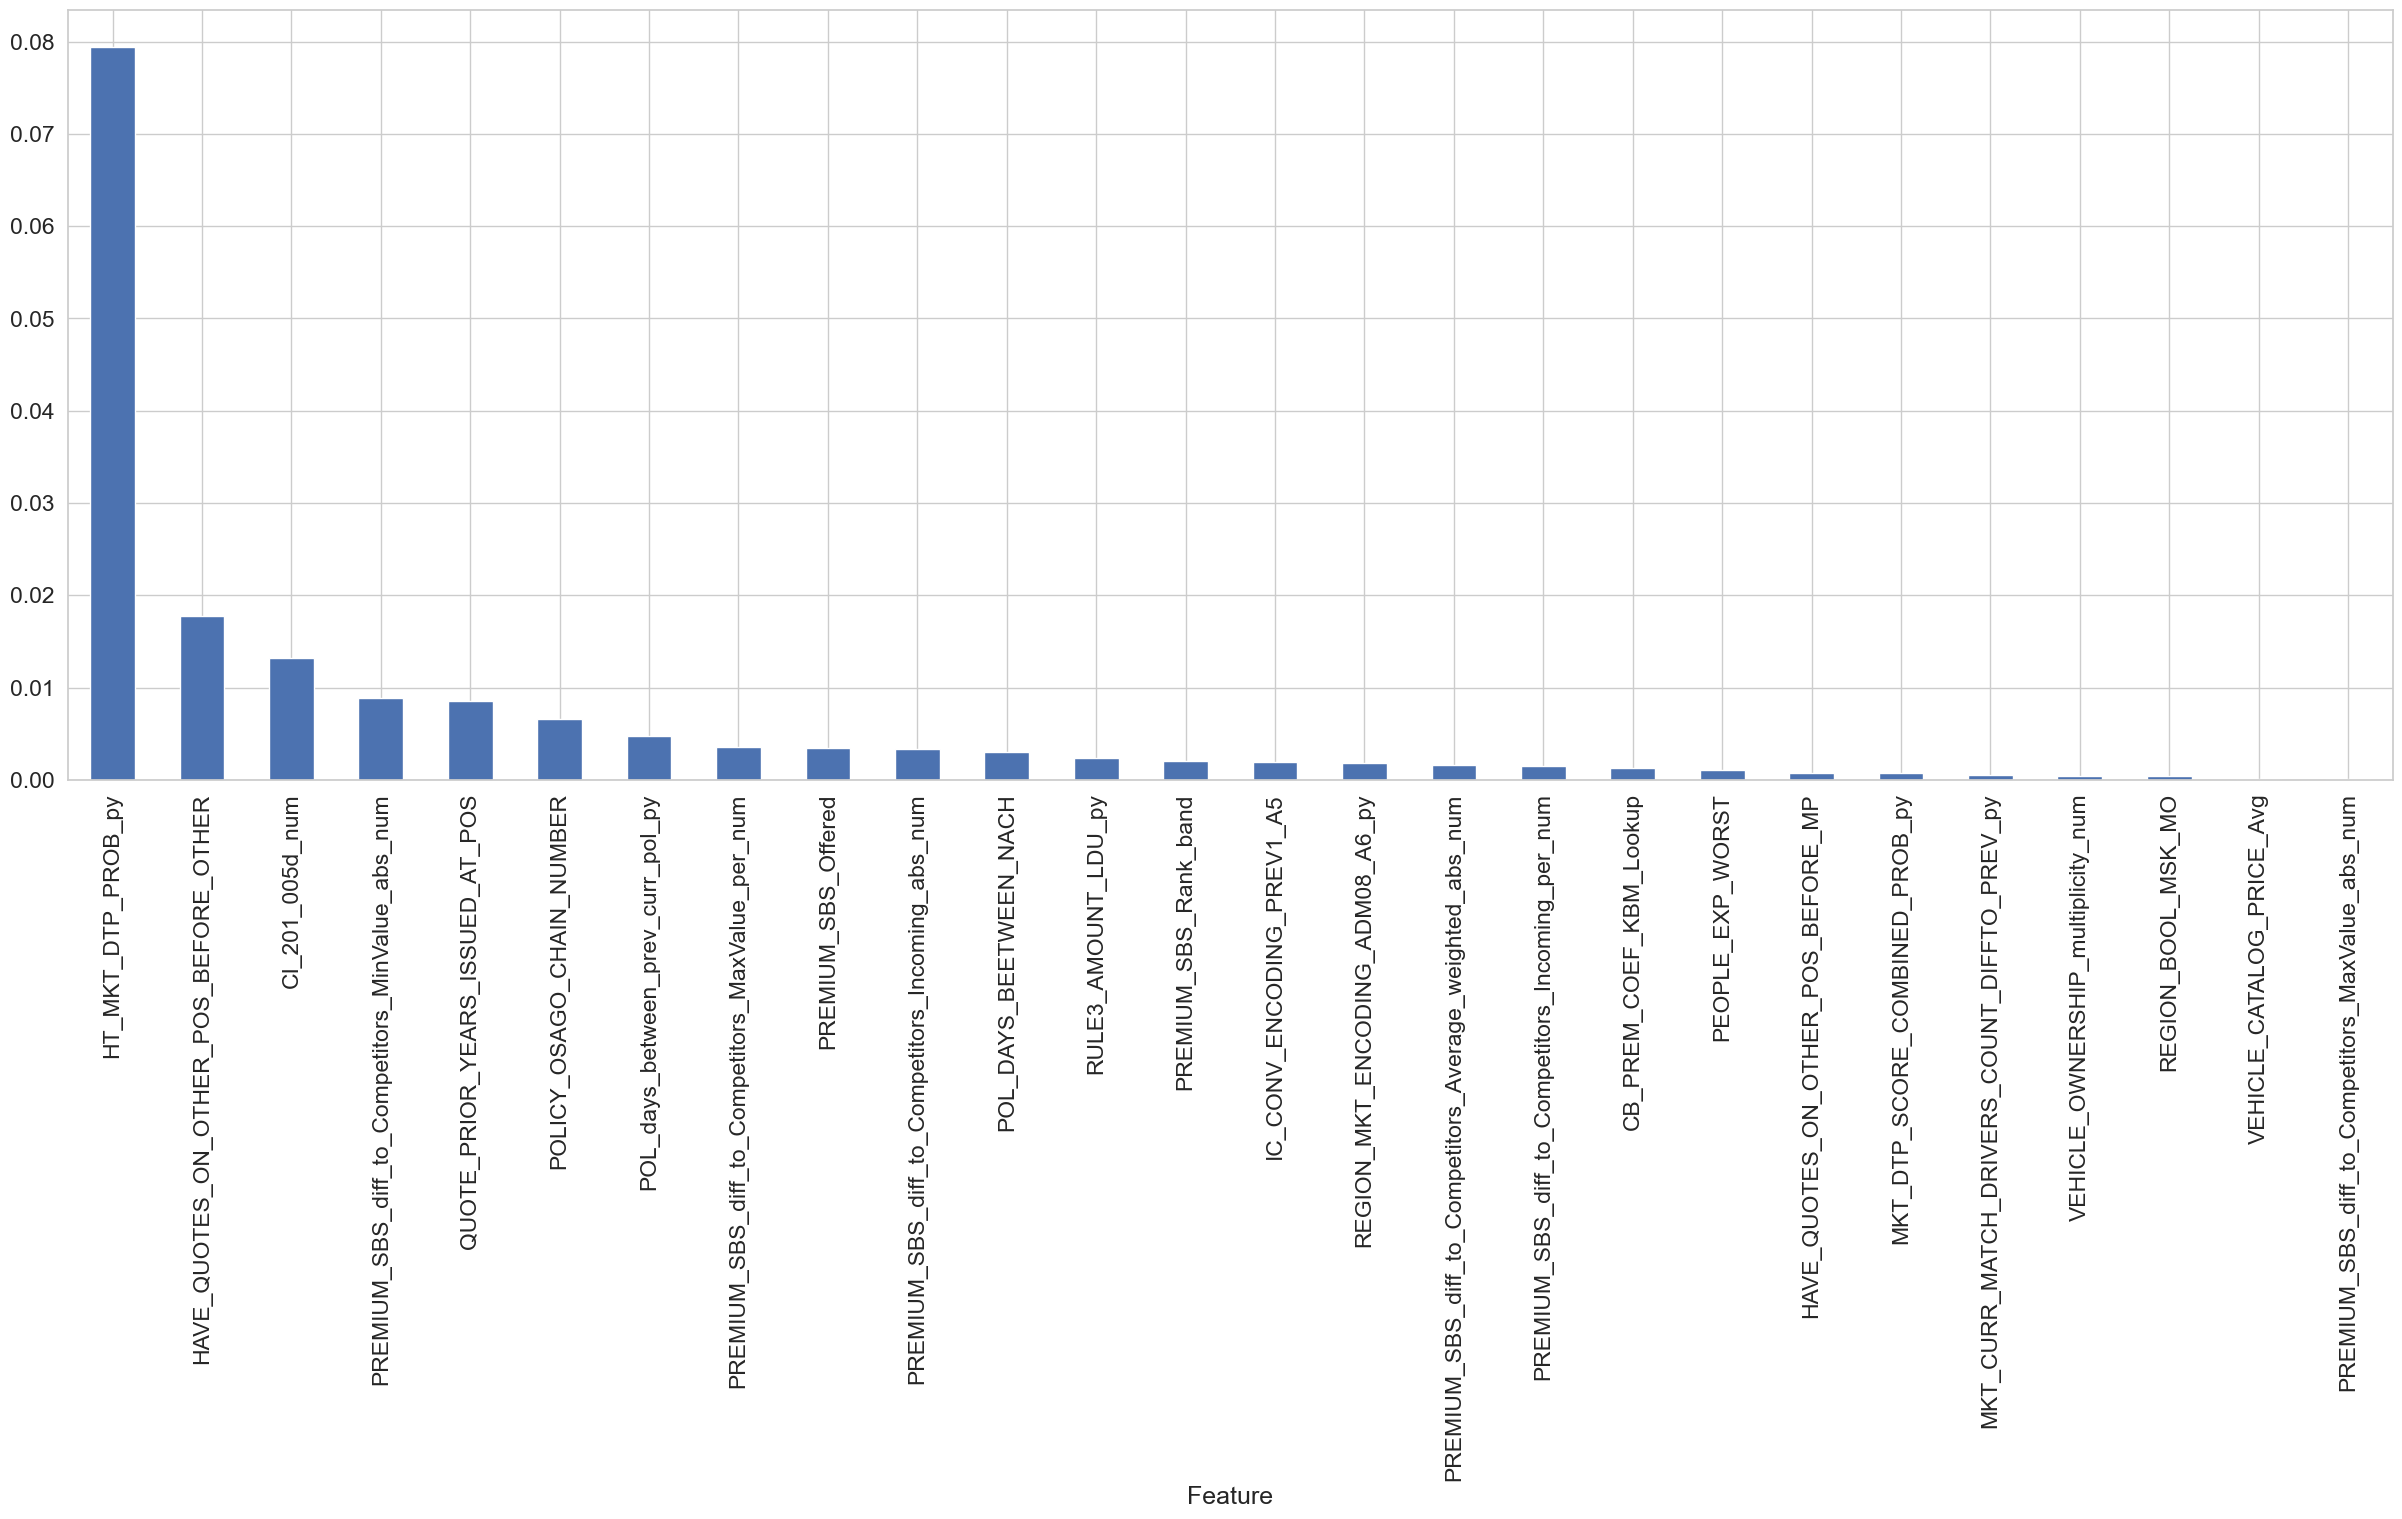

In [77]:
# Permutation Feature Importance
if True:
    accurate_fi = automl_rd.model.get_feature_scores('accurate', df_test.sample(frac = 0.2), silent = True)
    accurate_fi.set_index('Feature')['Importance'].plot.bar(figsize = (30, 10), grid = True)
    accurate_fi.to_csv('df_TEST_LAMA_FI_permutation.csv', sep=';', encoding = 'cp1251', decimal =',')

# 0X. PARITY - Time trend daily/weekly

### --- make PARITY db

In [78]:
DATE_COL = "TECHDATA_RUNDATE"
SPLIT_COL = "DB_SPLIT"
WEEK_COL = "QUOTE_CLC_Year_week"
TARGET_COL = "Response"

In [79]:
train_pred_type_OOF = False
if train_pred_type_OOF:
    PRED_NAME_TAKEN_COL = 'Pred_oof_LAMA'
    prediction_type_lbl = "TRAIN_OOF"
else:
    PRED_NAME_TAKEN_COL = 'Pred_fin_LAMA'
    prediction_type_lbl = "TRAIN_FIN"

df_train_scored_tmp = df_train[[DATE_COL, SPLIT_COL, WEEK_COL, TARGET_COL, PRED_NAME_TAKEN_COL]].copy()
df_train_scored_tmp.rename(columns={PRED_NAME_TAKEN_COL: 'pred_lama'}, inplace=True)
df_train_scored_tmp["prediction_type"] = prediction_type_lbl
df_train_scored_tmp["UNIQUE_ID"] = df_train_scored_tmp.index

In [80]:
PRED_NAME_TAKEN_COL = 'Pred_fin_LAMA'
df_oot_scored_tmp = df_test[[DATE_COL, SPLIT_COL, WEEK_COL, TARGET_COL, PRED_NAME_TAKEN_COL]].copy()
df_oot_scored_tmp.rename(columns={PRED_NAME_TAKEN_COL: 'pred_lama'}, inplace=True)
df_oot_scored_tmp["prediction_type"] = "OOT_PREDICT"
df_oot_scored_tmp["UNIQUE_ID"] = df_oot_scored_tmp.index

In [81]:
df_scored_tmp = pd.concat([df_train_scored_tmp, df_oot_scored_tmp], ignore_index=True)

In [82]:
df_scored_tmp["run_date"] = pd.to_datetime(df_scored_tmp[DATE_COL], errors="coerce").dt.floor("D")

In [83]:
df_scored_tmp["run_week"] = pd.to_datetime(df_scored_tmp[DATE_COL], errors="coerce").dt.to_period('W').dt.start_time
WEEK_COL = "run_week"

In [84]:
df_scored_tmp = df_scored_tmp.sort_values(["run_date", SPLIT_COL]).reset_index(drop=True)

In [85]:
df_scored_tmp

,TECHDATA_RUNDATE,DB_SPLIT,QUOTE_CLC_Year_week,Response,pred_lama,prediction_type,UNIQUE_ID,run_date,run_week
0,2026-01-12 09:35:53,TRAIN,2026-03,0,0.123428,TRAIN_FIN,d7588b02-33be-45ce-9ed3-8955f5731c5c,2026-01-12,2026-01-12
1,2026-01-12 20:01:25,TRAIN,2026-03,0,0.443449,TRAIN_FIN,4c929a3c-66b1-42f8-85f8-3a9251a0423e,2026-01-12,2026-01-12
2,2026-01-12 07:50:27,TRAIN,2026-03,0,0.004648,TRAIN_FIN,46587d46-2a23-4ae8-b776-51e34e1a584c,2026-01-12,2026-01-12
3,2026-01-12 11:44:59,TRAIN,2026-03,0,0.005207,TRAIN_FIN,c7e24d71-8cf1-4e65-b656-f7b1f1693106,2026-01-12,2026-01-12
4,2026-01-12 09:56:33,TRAIN,2026-03,0,0.000530,TRAIN_FIN,bec93534-6093-46cb-97a9-ddac49d6f8ff,2026-01-12,2026-01-12
...,...,...,...,...,...,...,...,...,...
1041570,2026-04-19 15:55:56,OOT,2026-16,0,0.008968,OOT_PREDICT,e14a0a0d-163d-4c2b-9229-6ef8f385179f,2026-04-19,2026-04-13
1041571,2026-04-19 06:18:00,OOT,2026-16,0,0.004542,OOT_PREDICT,875cc96d-ec57-4b1c-8ea8-3cee5db191e2,2026-04-19,2026-04-13
1041572,2026-04-19 13:24:24,OOT,2026-16,0,0.083429,OOT_PREDICT,4a0aeb3b-91bc-4652-996e-344a8d5468ea,2026-04-19,2026-04-13
1041573,2026-04-19 17:32:26,OOT,2026-16,0,0.003470,OOT_PREDICT,9e1b4556-5224-4944-9ae5-1e2c8aad3577,2026-04-19,2026-04-13


### --- make db for SBERDS Calibration test

In [86]:
df_scored_sber_ds = df_scored_tmp.copy()

#### ---- make TRAIN/TEST labels mapping

In [87]:
# make TRAIN/TEST labels mapping
DB_SPLIT_labels_mapping = {
    'TRAIN': 	'TRAIN',
    'OOT': 	    'TEST'
}
df_scored_sber_ds['DB_SPLIT'] = df_scored_sber_ds['DB_SPLIT'].map(DB_SPLIT_labels_mapping).fillna("TRAIN")

In [88]:
# cap by dates if required
if False:
    from datetime import datetime, date
    t1_ed = datetime(2026,1,1)
    t2_ed = datetime(2026,4,27)

    df_scored_sber_ds = df_scored_sber_ds[(df_scored_sber_ds [TIME_TREND_FACTOR] >= t1_ed) & (df_scored_sber_ds [TIME_TREND_FACTOR] < t2_ed)]

    print('min:\t', df_scored_sber_ds[TIME_TREND_FACTOR].min())
    print('max:\t', df_scored_sber_ds[TIME_TREND_FACTOR].max())

#### ---- extract db

In [89]:
df_scored_sber_ds

,TECHDATA_RUNDATE,DB_SPLIT,QUOTE_CLC_Year_week,Response,pred_lama,prediction_type,UNIQUE_ID,run_date,run_week
0,2026-01-12 09:35:53,TRAIN,2026-03,0,0.123428,TRAIN_FIN,d7588b02-33be-45ce-9ed3-8955f5731c5c,2026-01-12,2026-01-12
1,2026-01-12 20:01:25,TRAIN,2026-03,0,0.443449,TRAIN_FIN,4c929a3c-66b1-42f8-85f8-3a9251a0423e,2026-01-12,2026-01-12
2,2026-01-12 07:50:27,TRAIN,2026-03,0,0.004648,TRAIN_FIN,46587d46-2a23-4ae8-b776-51e34e1a584c,2026-01-12,2026-01-12
3,2026-01-12 11:44:59,TRAIN,2026-03,0,0.005207,TRAIN_FIN,c7e24d71-8cf1-4e65-b656-f7b1f1693106,2026-01-12,2026-01-12
4,2026-01-12 09:56:33,TRAIN,2026-03,0,0.000530,TRAIN_FIN,bec93534-6093-46cb-97a9-ddac49d6f8ff,2026-01-12,2026-01-12
...,...,...,...,...,...,...,...,...,...
1041570,2026-04-19 15:55:56,TEST,2026-16,0,0.008968,OOT_PREDICT,e14a0a0d-163d-4c2b-9229-6ef8f385179f,2026-04-19,2026-04-13
1041571,2026-04-19 06:18:00,TEST,2026-16,0,0.004542,OOT_PREDICT,875cc96d-ec57-4b1c-8ea8-3cee5db191e2,2026-04-19,2026-04-13
1041572,2026-04-19 13:24:24,TEST,2026-16,0,0.083429,OOT_PREDICT,4a0aeb3b-91bc-4652-996e-344a8d5468ea,2026-04-19,2026-04-13
1041573,2026-04-19 17:32:26,TEST,2026-16,0,0.003470,OOT_PREDICT,9e1b4556-5224-4944-9ae5-1e2c8aad3577,2026-04-19,2026-04-13


In [90]:
df_scored_sber_ds[['UNIQUE_ID', 'DB_SPLIT','run_week', 'pred_lama', 'Response']].to_csv('df_scored_sber_ds.csv', index=False, sep=';', encoding = 'cp1251', decimal ='.')

In [91]:
df_scored_sber_ds[['UNIQUE_ID', 'DB_SPLIT','run_week', 'pred_lama', 'Response']].to_csv('df_scored_sber_ds_dfltformat.csv', index=False)

In [92]:
df_scored_sber_ds_test = df_scored_sber_ds[df_scored_sber_ds['DB_SPLIT']=='TEST'].copy()

In [93]:
df_scored_sber_ds_test

,TECHDATA_RUNDATE,DB_SPLIT,QUOTE_CLC_Year_week,Response,pred_lama,prediction_type,UNIQUE_ID,run_date,run_week
701400,2026-03-23 09:41:01,TEST,2026-13,0,0.014299,OOT_PREDICT,9e05afc2-0bfb-4e7d-878f-4ea98bd5d836,2026-03-23,2026-03-23
701401,2026-03-23 12:37:19,TEST,2026-13,0,0.031421,OOT_PREDICT,e61139b7-4b25-4f05-ac07-3d5cc828e613,2026-03-23,2026-03-23
701402,2026-03-23 12:05:41,TEST,2026-13,1,0.789743,OOT_PREDICT,e267b2f6-b4b5-4618-8fb4-3ea898ec5d5f,2026-03-23,2026-03-23
701403,2026-03-23 10:15:11,TEST,2026-13,0,0.005997,OOT_PREDICT,6f5b3504-dffd-4d87-96db-e494fd047bf7,2026-03-23,2026-03-23
701404,2026-03-23 11:19:03,TEST,2026-13,0,0.002929,OOT_PREDICT,cc12fe85-1b56-4af1-9fcf-9e72746a9705,2026-03-23,2026-03-23
...,...,...,...,...,...,...,...,...,...
1041570,2026-04-19 15:55:56,TEST,2026-16,0,0.008968,OOT_PREDICT,e14a0a0d-163d-4c2b-9229-6ef8f385179f,2026-04-19,2026-04-13
1041571,2026-04-19 06:18:00,TEST,2026-16,0,0.004542,OOT_PREDICT,875cc96d-ec57-4b1c-8ea8-3cee5db191e2,2026-04-19,2026-04-13
1041572,2026-04-19 13:24:24,TEST,2026-16,0,0.083429,OOT_PREDICT,4a0aeb3b-91bc-4652-996e-344a8d5468ea,2026-04-19,2026-04-13
1041573,2026-04-19 17:32:26,TEST,2026-16,0,0.003470,OOT_PREDICT,9e1b4556-5224-4944-9ae5-1e2c8aad3577,2026-04-19,2026-04-13


In [94]:
df_scored_sber_ds_test[['UNIQUE_ID', 'DB_SPLIT','run_week', 'pred_lama', 'Response']].to_csv('df_scored_sber_ds_test.csv', index=False, sep=';', encoding = 'cp1251', decimal ='.')

In [95]:
df_scored_sber_ds_test[['UNIQUE_ID', 'DB_SPLIT','run_week', 'pred_lama', 'Response']].to_csv('df_scored_sber_ds_test_dfltformat.csv', index=False)

### --- PARITY calc

In [96]:
from pathlib import Path

if Path.cwd().name == "notebooks":
    PROJECT_DIR = Path.cwd().parent
else:
    PROJECT_DIR = Path.cwd()

PLOTS_DIR = PROJECT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

#### ----- weekly trend

In [97]:
WEEKLY_CSV = PLOTS_DIR / "PARITY_weekly.csv"

,DB_SPLIT,run_week,prediction_type,rows,actual,pred_lama,prints,bias
4,TRAIN,2026-01-12,TRAIN_FIN,71589,0.115339,0.111781,8257,-0.003558
5,TRAIN,2026-01-19,TRAIN_FIN,68331,0.096940,0.095179,6624,-0.001761
6,TRAIN,2026-01-26,TRAIN_FIN,59796,0.094789,0.094478,5668,-0.000311
7,TRAIN,2026-02-02,TRAIN_FIN,67191,0.091411,0.096202,6142,0.004791
8,TRAIN,2026-02-09,TRAIN_FIN,74133,0.091943,0.092387,6816,0.000444
9,TRAIN,2026-02-16,TRAIN_FIN,65786,0.082601,0.085101,5434,0.002499
10,TRAIN,2026-02-23,TRAIN_FIN,65978,0.082528,0.085694,5445,0.003166
11,TRAIN,2026-03-02,TRAIN_FIN,66014,0.085861,0.089022,5668,0.003162
12,TRAIN,2026-03-09,TRAIN_FIN,79390,0.094710,0.095383,7519,0.000674
13,TRAIN,2026-03-16,TRAIN_FIN,83192,0.094997,0.098224,7903,0.003227


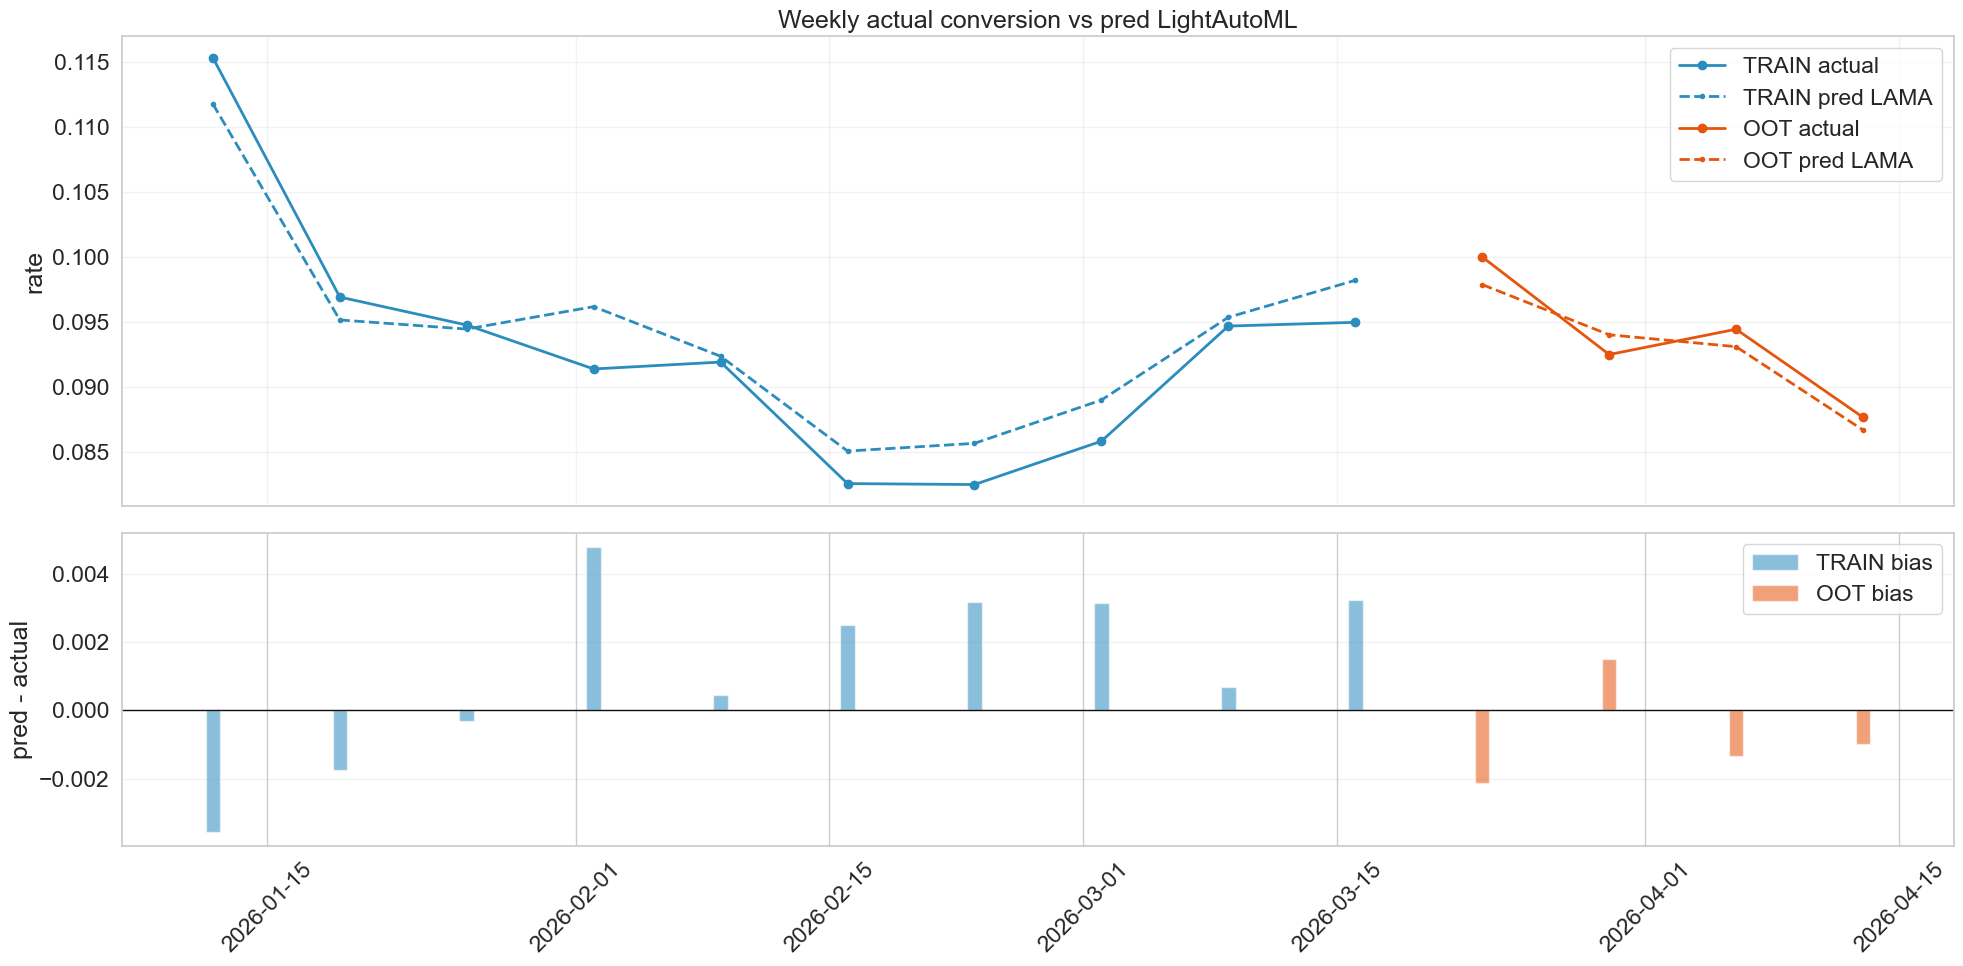

saved: e:\PubPricing\01_Retail\02_OMTPL\01_Modelling\01_Risk\2025m09\05_Opt\2026w29\02_TR\01_SRVN\03_LAMA\Run002\Run002_02\Run002_02_05_01_ReRunMode1_RD\plots\04_lama_raw_weekly_actual_vs_pred.png


In [98]:
weekly = (
    df_scored_tmp.groupby([SPLIT_COL, WEEK_COL, "prediction_type"])
    .agg(
        rows=(TARGET_COL, "size"),
        actual=(TARGET_COL, "mean"),
        pred_lama=("pred_lama", "mean"),
        prints=(TARGET_COL, "sum"),
    )
    .reset_index()
    .sort_values(WEEK_COL)
)
weekly["bias"] = weekly["pred_lama"] - weekly["actual"]
weekly.to_csv(WEEKLY_CSV, index=False, sep=';', encoding = 'cp1251', decimal =',')
display(weekly)
# print("weekly saved:", WEEKLY_CSV)

fig, axes = plt.subplots(2, 1, figsize=(20, 10), sharex=True, gridspec_kw={"height_ratios": [1.2, 0.8]})

split_color_catalog = [("TRAIN", "#2b8cbe"), ("OOT", "#e6550d")]

for split, color in split_color_catalog:
    d = weekly[weekly[SPLIT_COL] == split].sort_values(WEEK_COL)
    if d.empty:
        continue
    axes[0].plot(d[WEEK_COL], d["actual"], color=color, marker="o", lw=2, label=f"{split} actual")
    axes[0].plot(d[WEEK_COL], d["pred_lama"], color=color, marker=".", lw=2, ls="--", label=f"{split} pred LAMA")
    axes[1].bar(d[WEEK_COL], d["bias"], color=color, alpha=0.55, label=f"{split} bias")

axes[0].set_title("Weekly actual conversion vs pred LightAutoML")
axes[0].set_ylabel("rate")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best")

axes[1].axhline(0, color="#111111", lw=1)
axes[1].set_ylabel("pred - actual")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(loc="best")

plt.xticks(rotation=45)
fig.tight_layout()
out_path = PLOTS_DIR / "04_lama_raw_weekly_actual_vs_pred.png"
fig.savefig(out_path, dpi=170)
plt.show()
print("saved:", out_path)

#### ----- daily trend

In [99]:
DAILY_CSV = PLOTS_DIR / "PARITY_daily.csv"

,DB_SPLIT,run_date,prediction_type,rows,actual,pred_lama,prints,bias
28,TRAIN,2026-01-12,TRAIN_FIN,11967,0.118242,0.112439,1415,-0.005803
29,TRAIN,2026-01-13,TRAIN_FIN,11033,0.114293,0.110176,1261,-0.004117
30,TRAIN,2026-01-14,TRAIN_FIN,11662,0.116361,0.113635,1357,-0.002726
31,TRAIN,2026-01-15,TRAIN_FIN,11967,0.120164,0.117342,1438,-0.002822
32,TRAIN,2026-01-16,TRAIN_FIN,9932,0.111559,0.109241,1108,-0.002317


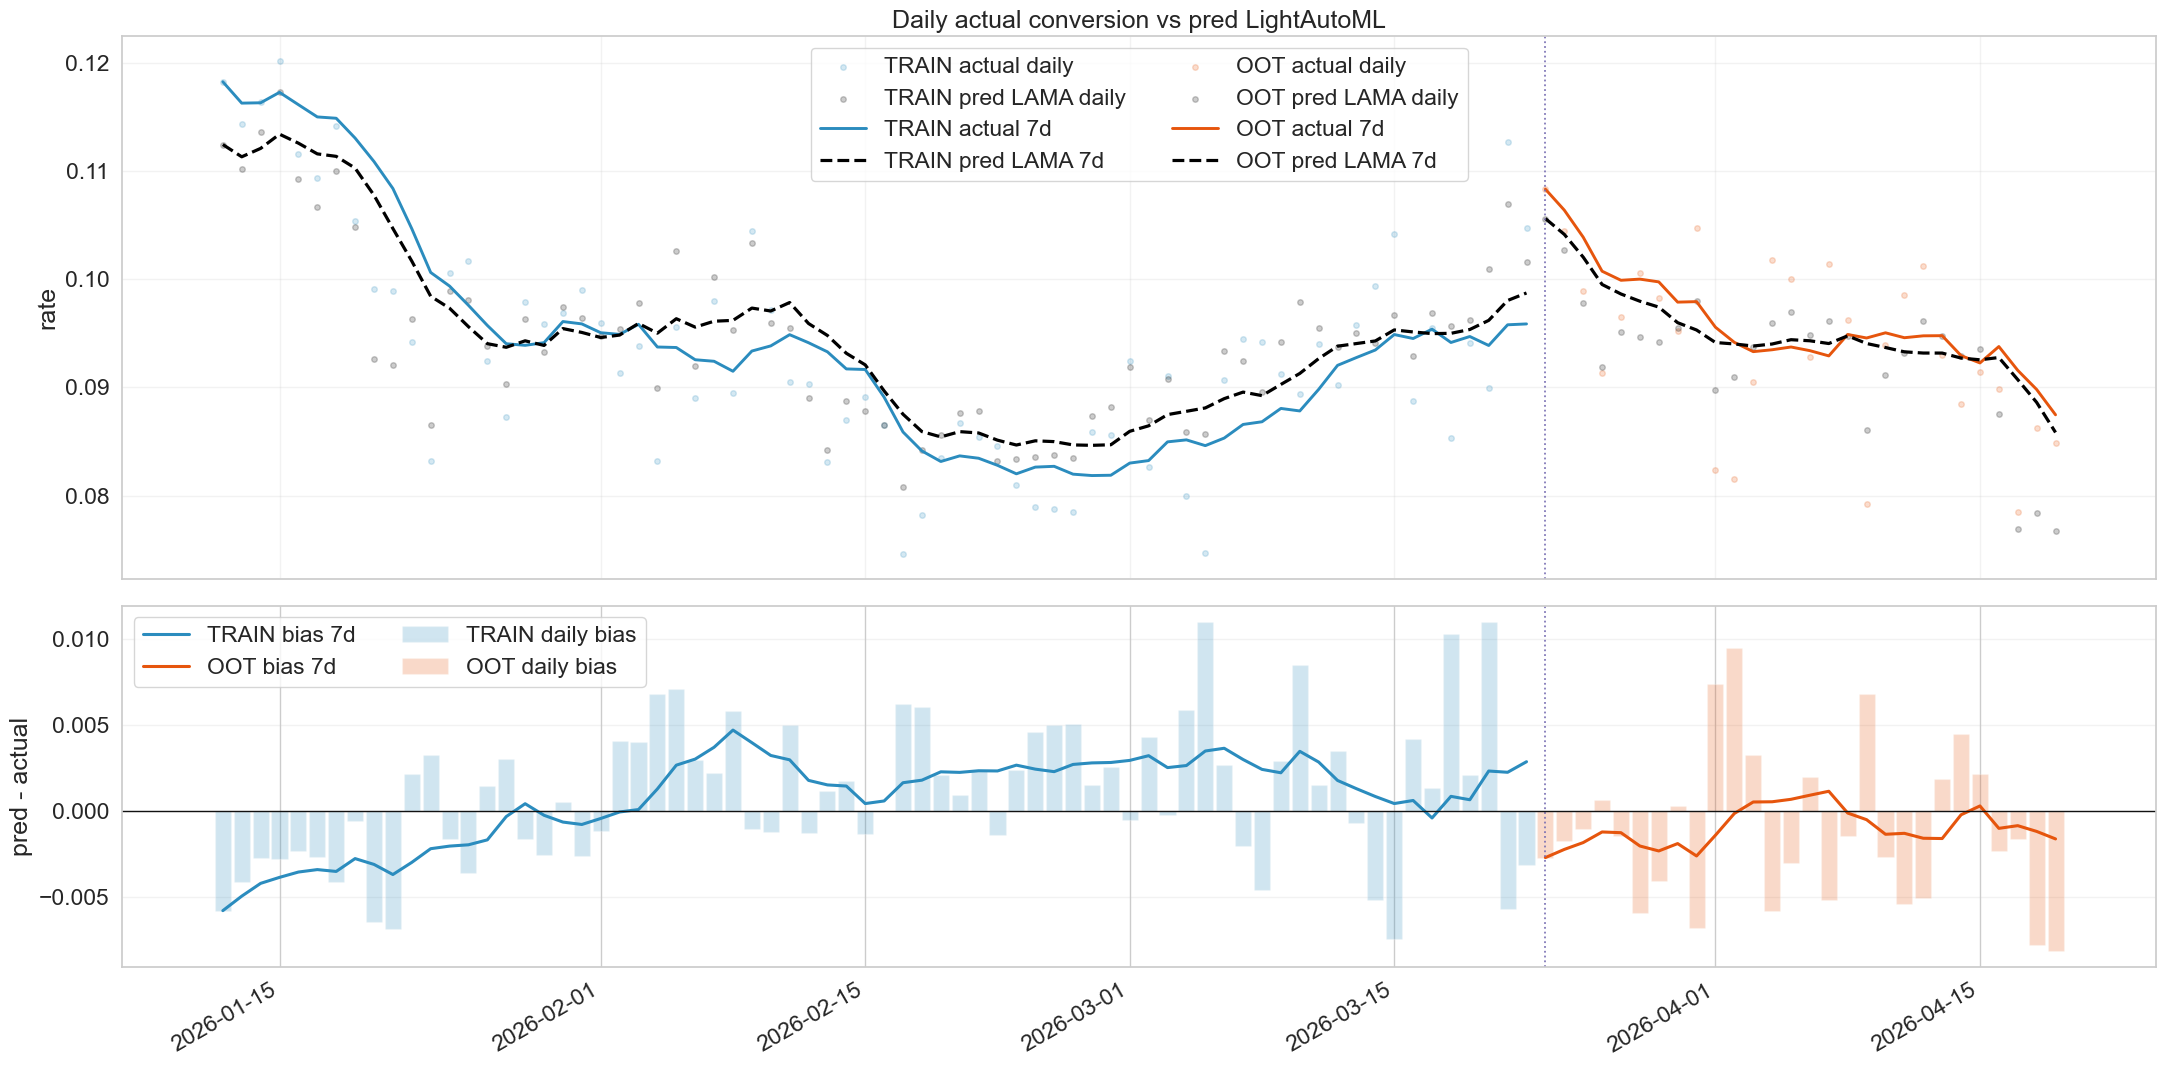

saved: e:\PubPricing\01_Retail\02_OMTPL\01_Modelling\01_Risk\2025m09\05_Opt\2026w29\02_TR\01_SRVN\03_LAMA\Run002\Run002_02\Run002_02_05_01_ReRunMode1_RD\plots\05_lama_raw_daily_actual_vs_pred.png


In [100]:
daily = (
    df_scored_tmp.groupby([SPLIT_COL, "run_date", "prediction_type"])
    .agg(
        rows=(TARGET_COL, "size"),
        actual=(TARGET_COL, "mean"),
        pred_lama=("pred_lama", "mean"),
        prints=(TARGET_COL, "sum"),
    )
    .reset_index()
    .sort_values("run_date")
)
daily["bias"] = daily["pred_lama"] - daily["actual"]
daily.to_csv(DAILY_CSV, index=False, sep=';', encoding = 'cp1251', decimal =',')
display(daily.head())
#print("daily saved:", DAILY_CSV)

fig, axes = plt.subplots(2, 1, figsize=(22, 11), sharex=True, gridspec_kw={"height_ratios": [1.2, 0.8]})

split_color_catalog = [("TRAIN", "#2b8cbe"), ("OOT", "#e6550d")]

for split, color in split_color_catalog:
    d = daily[daily[SPLIT_COL] == split].sort_values("run_date").copy()
    if d.empty:
        continue
    d["actual_roll7"] = d["actual"].rolling(7, min_periods=1).mean()
    d["pred_roll7"] = d["pred_lama"].rolling(7, min_periods=1).mean()
    d["bias_roll7"] = d["bias"].rolling(7, min_periods=1).mean()

    axes[0].scatter(d["run_date"], d["actual"], color=color, alpha=0.20, s=16, label=f"{split} actual daily")
    axes[0].scatter(d["run_date"], d["pred_lama"], color='black', alpha=0.20, s=16, label=f"{split} pred LAMA daily") ###
    axes[0].plot(d["run_date"], d["actual_roll7"], color=color, lw=2.1, label=f"{split} actual 7d")
    axes[0].plot(d["run_date"], d["pred_roll7"], color='black', lw=2.3, ls="--", label=f"{split} pred LAMA 7d")

    axes[1].bar(d["run_date"], d["bias"], color=color, alpha=0.22, width=0.85, label=f"{split} daily bias")
    axes[1].plot(d["run_date"], d["bias_roll7"], color=color, lw=2.2, label=f"{split} bias 7d")

oot_start = daily.loc[daily[SPLIT_COL] == "OOT", "run_date"].min()
if pd.notna(oot_start):
    for ax in axes:
        ax.axvline(oot_start, color="#756bb1", lw=1.3, ls=":", alpha=0.9)

axes[0].set_title("Daily actual conversion vs pred LightAutoML")
axes[0].set_ylabel("rate")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="best", ncol=2)

axes[1].axhline(0, color="#111111", lw=1)
axes[1].set_ylabel("pred - actual")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(loc="best", ncol=2)

fig.autofmt_xdate()
fig.tight_layout()
out_path = PLOTS_DIR / "05_lama_raw_daily_actual_vs_pred.png"
fig.savefig(out_path, dpi=170)
plt.show()
print("saved:", out_path)

### 12.1. Score-bin калибровка

Бины строятся только по TRAIN OOF score. Затем теми же границами режем OOT. Если в каждом bin на OOT факт выше прогноза, это общий level-shift. Если проблема только в отдельных bin, это локальная некалиброванность score.

In [101]:
def make_train_score_edges(train_scores: pd.Series, n_bins: int = 10) -> np.ndarray:
    qs = np.linspace(0, 1, n_bins + 1)
    edges = train_scores.quantile(qs).to_numpy()
    edges = np.unique(edges)
    edges[0] = -np.inf
    edges[-1] = np.inf
    return edges


def assign_bins(scores: pd.Series, edges: np.ndarray) -> pd.Series:
    return pd.cut(scores, bins=edges, include_lowest=True, duplicates="drop")


score_edges = make_train_score_edges(
    df_scored_tmp.loc[df_scored_tmp[SPLIT_COL].eq("TRAIN"), "pred_lama"],
    n_bins=10,
)
df_scored_tmp["score_bin"] = assign_bins(df_scored_tmp["pred_lama"], score_edges)

score_bin_diag = (
    df_scored_tmp.groupby([SPLIT_COL, "prediction_type", "score_bin"], observed=True)
    .agg(
        rows=(TARGET_COL, "size"),
        purchases=(TARGET_COL, "sum"),
        actual=(TARGET_COL, "mean"),
        pred=("pred_lama", "mean"),
        score_min=("pred_lama", "min"),
        score_max=("pred_lama", "max"),
    )
    .reset_index()
)
score_bin_diag["bias"] = score_bin_diag["pred"] - score_bin_diag["actual"]
score_bin_diag["rel_bias_pct"] = 100 * score_bin_diag["bias"] / score_bin_diag["actual"]
score_bin_diag["bin_id"] = score_bin_diag.groupby([SPLIT_COL, "prediction_type"]).cumcount() + 1
score_bin_diag.to_csv(PLOTS_DIR / "score_bin_calibration.csv", index=False, sep=';', encoding = 'cp1251', decimal =',')

display(score_bin_diag)

,DB_SPLIT,prediction_type,score_bin,rows,purchases,actual,pred,score_min,score_max,bias,rel_bias_pct,bin_id
0,OOT,OOT_PREDICT,"(-inf, 0.000699]",29868,2,0.000067,0.000453,0.000132,0.000699,0.000386,576.934515,1
1,OOT,OOT_PREDICT,"(0.000699, 0.00145]",32070,15,0.000468,0.001044,0.000699,0.001454,0.000576,123.119222,2
2,OOT,OOT_PREDICT,"(0.00145, 0.00288]",33667,53,0.001574,0.002092,0.001454,0.002883,0.000518,32.877037,3
3,OOT,OOT_PREDICT,"(0.00288, 0.00562]",34503,106,0.003072,0.004112,0.002883,0.005624,0.001040,33.854183,4
4,OOT,OOT_PREDICT,"(0.00562, 0.011]",35458,228,0.006430,0.008039,0.005624,0.011032,0.001609,25.028135,5
5,OOT,OOT_PREDICT,"(0.011, 0.0223]",35740,493,0.013794,0.015994,0.011033,0.022303,0.002200,15.947088,6
6,OOT,OOT_PREDICT,"(0.0223, 0.0482]",35687,1031,0.028890,0.033236,0.022304,0.048173,0.004346,15.042932,7
7,OOT,OOT_PREDICT,"(0.0482, 0.115]",35581,2630,0.073916,0.076270,0.048175,0.114760,0.002355,3.185473,8
8,OOT,OOT_PREDICT,"(0.115, 0.314]",34647,6955,0.200739,0.192074,0.114766,0.313495,-0.008665,-4.316330,9
9,OOT,OOT_PREDICT,"(0.314, inf]",32954,20354,0.617649,0.606217,0.313531,0.985957,-0.011432,-1.850918,10


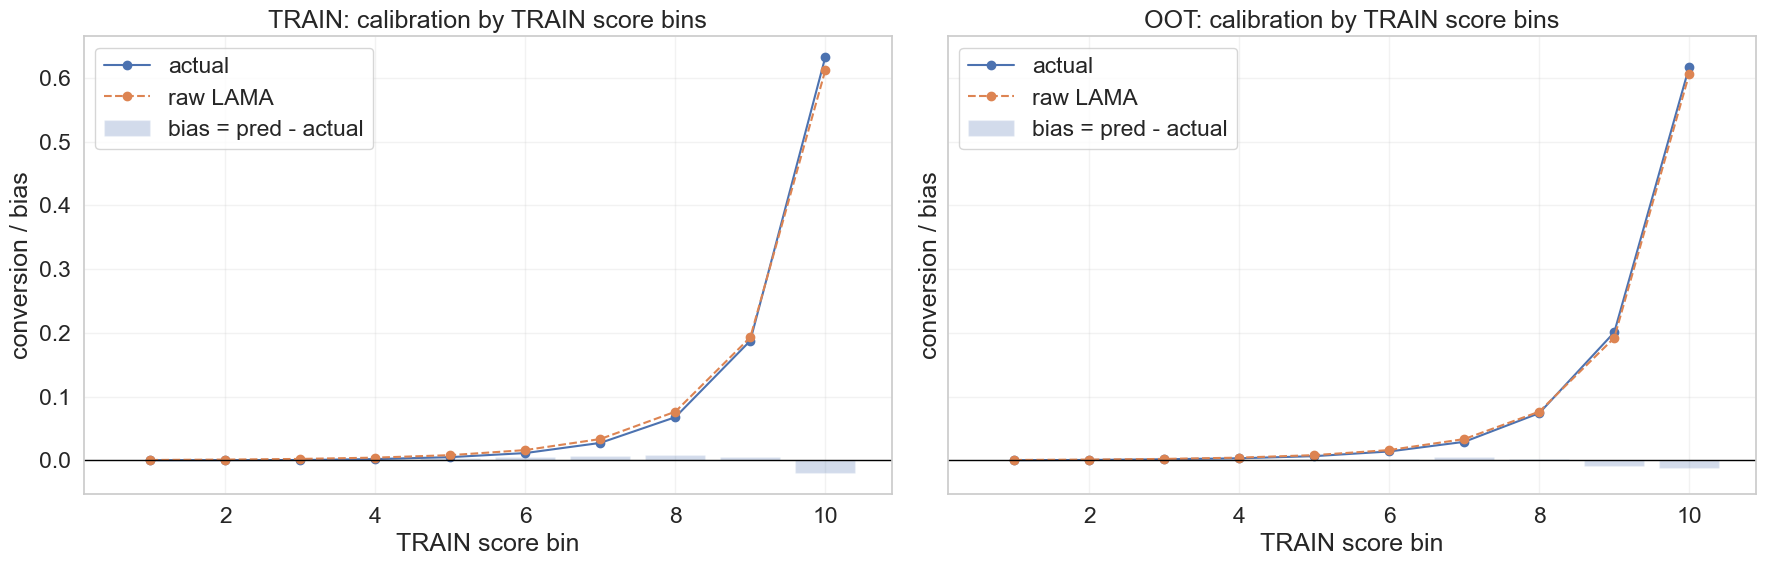

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for ax, split in zip(axes, ["TRAIN", "OOT"]):
    part = score_bin_diag[score_bin_diag[SPLIT_COL].eq(split)].sort_values("bin_id")
    ax.plot(part["bin_id"], part["actual"], marker="o", label="actual")
    ax.plot(part["bin_id"], part["pred"], marker="o", linestyle="--", label="raw LAMA")
    ax.bar(part["bin_id"], part["bias"], alpha=0.25, label="bias = pred - actual")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"{split}: calibration by TRAIN score bins")
    ax.set_xlabel("TRAIN score bin")
    ax.set_ylabel("conversion / bias")
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_score_bin_calibration_train_oot.png", dpi=160)
plt.show()

In [103]:
split_diag = (
    df_scored_tmp.groupby([SPLIT_COL, "prediction_type"])
    .agg(
        rows=(TARGET_COL, "size"),
        purchases=(TARGET_COL, "sum"),
        actual=(TARGET_COL, "mean"),
        pred=("pred_lama", "mean"),
        pred_std=("pred_lama", "std"),
        pred_p01=("pred_lama", lambda x: x.quantile(0.01)),
        pred_p10=("pred_lama", lambda x: x.quantile(0.10)),
        pred_p50=("pred_lama", "median"),
        pred_p90=("pred_lama", lambda x: x.quantile(0.90)),
        pred_p99=("pred_lama", lambda x: x.quantile(0.99)),
    )
    .reset_index()
)
split_diag["bias"] = split_diag["pred"] - split_diag["actual"]
split_diag["rel_bias_pct"] = 100 * split_diag["bias"] / split_diag["actual"]
split_diag.to_csv(PLOTS_DIR / "split_score_level_summary.csv", index=False, sep=';', encoding = 'cp1251', decimal =',')
split_diag

,DB_SPLIT,prediction_type,rows,purchases,actual,pred,pred_std,pred_p01,pred_p10,pred_p50,pred_p90,pred_p99,bias,rel_bias_pct
0,OOT,OOT_PREDICT,340175,31867,0.093678,0.093034,0.188415,0.000273,0.000778,0.012042,0.301416,0.878121,-0.000644,-0.687437
1,TRAIN,TRAIN_FIN,701400,65476,0.093350,0.094584,0.192727,0.000262,0.000699,0.011033,0.313508,0.888759,0.001234,1.321367
